In [242]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.append(parent_dir)
from functions.set_plot_settings import setPlotSettings
setPlotSettings(font=True)

from functions.read_g4bl_data import readDetData, readTraceData

In [243]:
tmagic = pd.read_csv('tmagic_vs_z.txt', sep=r'\s+', names=["z", "t"])
toffs = pd.read_csv('toffs_vs_z.txt', sep=r'\s+', names=["z", "t"])

In [244]:
tmagic

,z,t
0,-425.0,-0.771238
1,-175.0,0.134920
2,75.0,1.041078
3,325.0,1.947237
4,575.0,2.853395
...,...,...
374,130125.0,485.571380
375,130575.0,487.262880
376,130825.0,488.202610
377,131275.0,489.894120


In [245]:
toffs

,z,t
0,-425.0,1.796243
1,-175.0,1.796243
2,75.0,1.796243
3,325.0,1.796243
4,575.0,1.796243
...,...,...
374,130125.0,1.819043
375,130575.0,1.819043
376,130825.0,1.819043
377,131275.0,1.819043


In [246]:
ttotal = tmagic.copy()
ttotal['t'] = tmagic['t']+toffs['t']
ttotal

,z,t
0,-425.0,1.025005
1,-175.0,1.931163
2,75.0,2.837321
3,325.0,3.743480
4,575.0,4.649638
...,...,...
374,130125.0,487.390423
375,130575.0,489.081923
376,130825.0,490.021653
377,131275.0,491.713163


In [247]:
tlin = [np.min(tmagic['t']),np.max(tmagic['t'])]
zlin = [np.min(tmagic['z']),np.max(tmagic['z'])]

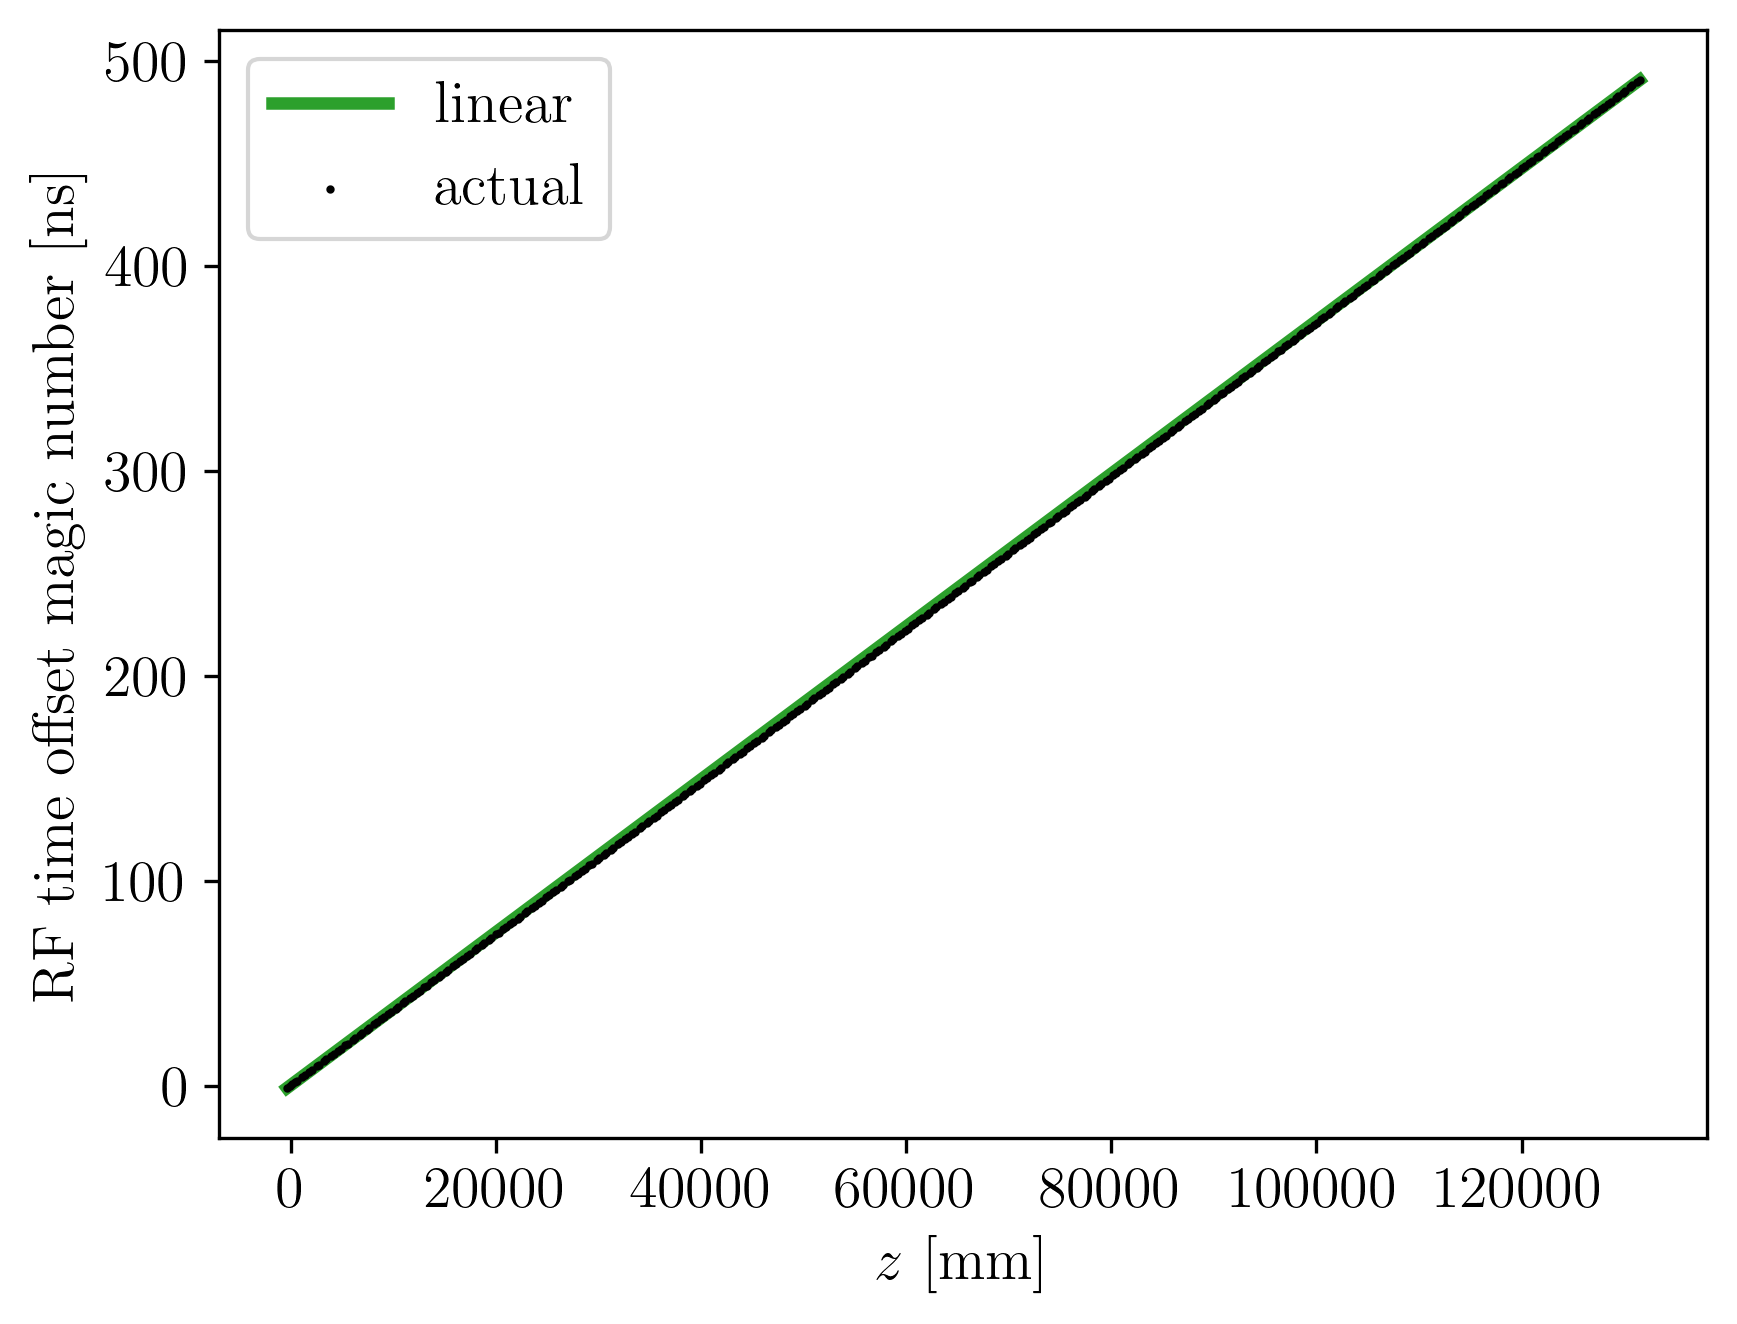

In [248]:
# plt.plot(tmagic['z'],tmagic['t'],color='tab:green',zorder=0,linewidth=3)
plt.plot(zlin,tlin,color='tab:green',zorder=0,linewidth=3,label='linear')
plt.scatter(tmagic['z'],tmagic['t'],s=1,color='black',label='actual')
plt.xlabel('$z$ [mm]')
plt.ylabel('RF time offset magic number [ns]')
plt.legend();

In [249]:
#position of first absorber
zabsi = 2250+4200
zabsf = 3650+29*4200

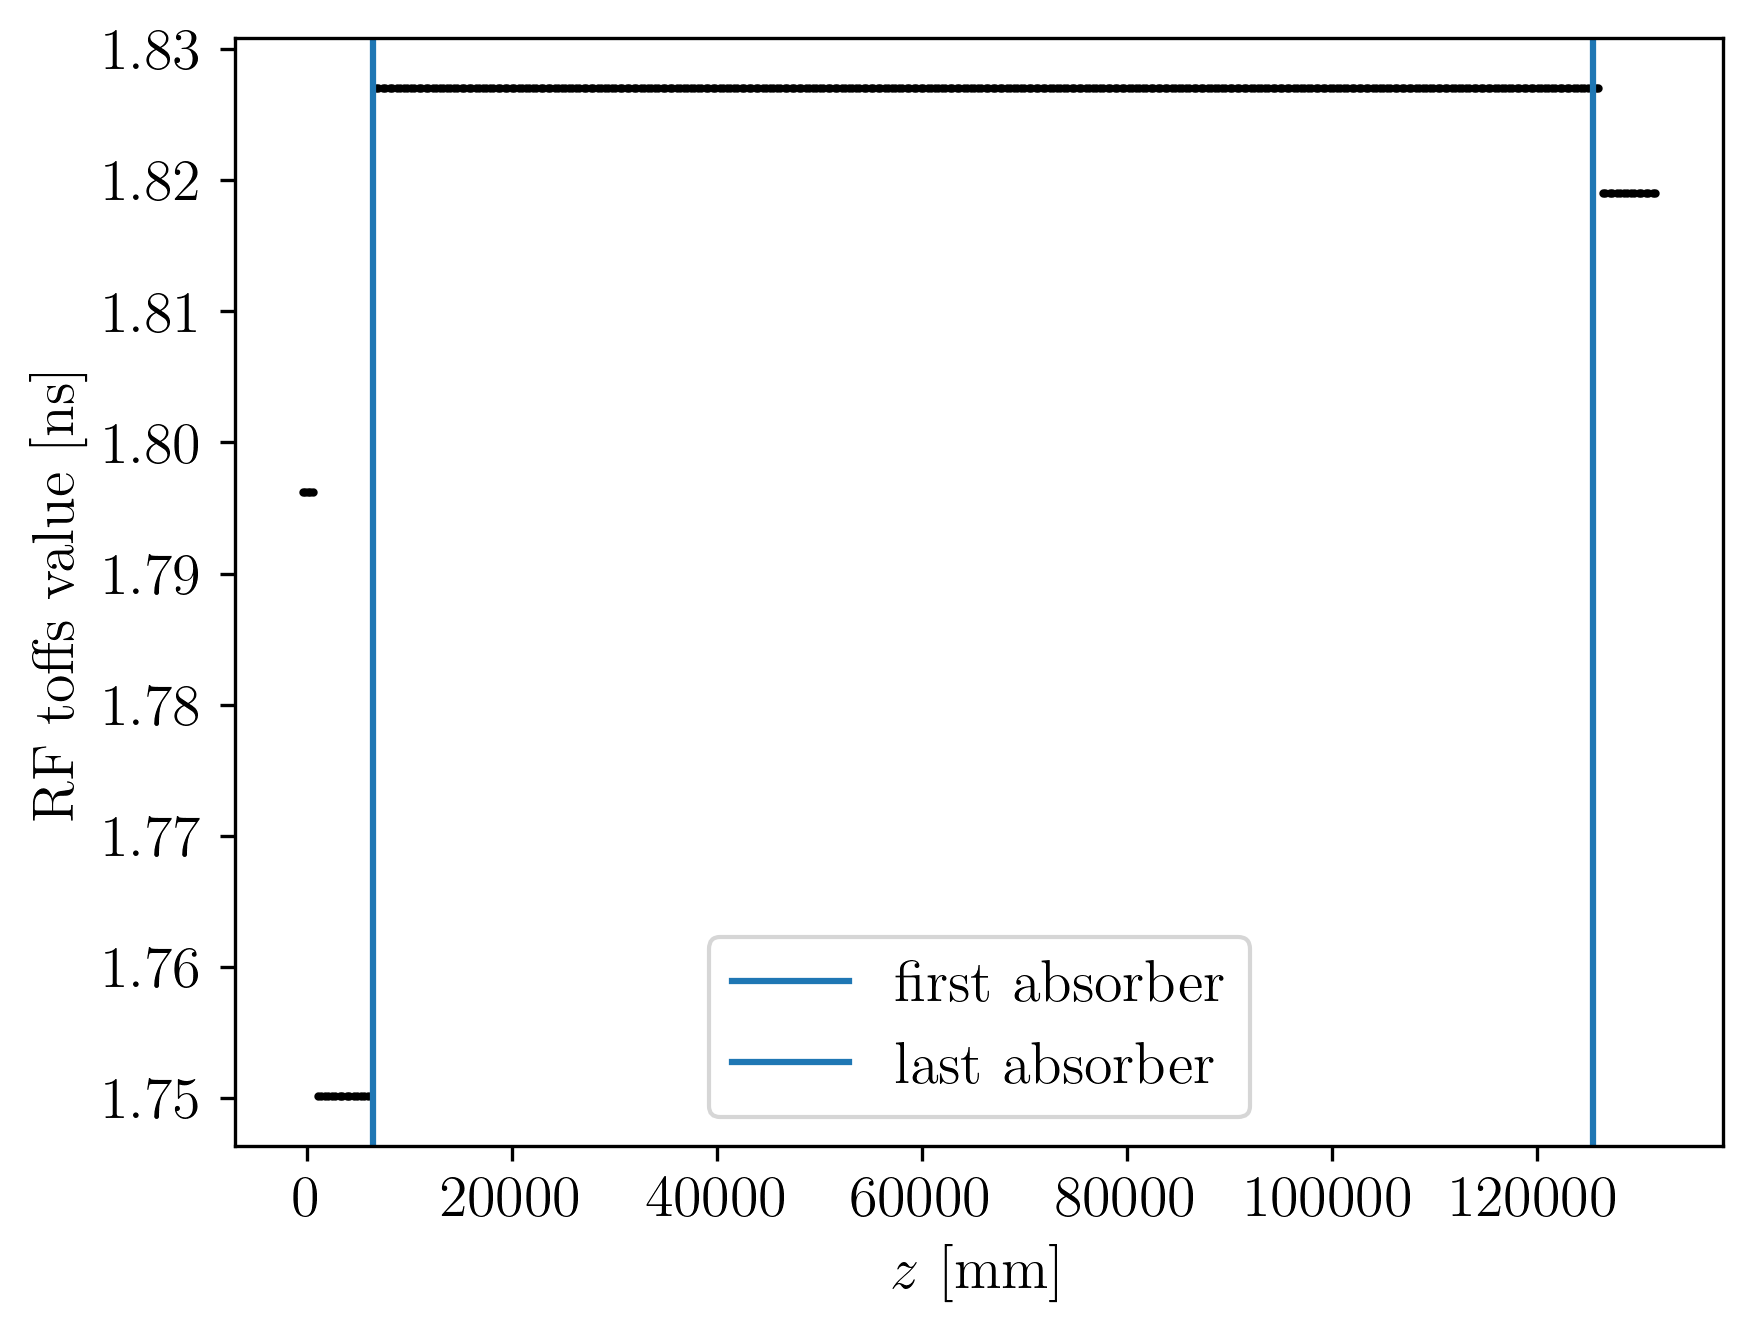

In [250]:
plt.scatter(toffs['z'],toffs['t'],s=1,color='black')
plt.xlabel('$z$ [mm]')
plt.ylabel('RF toffs value [ns]')
plt.axvline(zabsi,label='first absorber')
plt.axvline(zabsf,label='last absorber')
plt.legend();

In [251]:
tlin2 = [np.min(ttotal['t']),np.max(ttotal['t'])]
zlin2 = [np.min(ttotal['z']),np.max(ttotal['z'])]

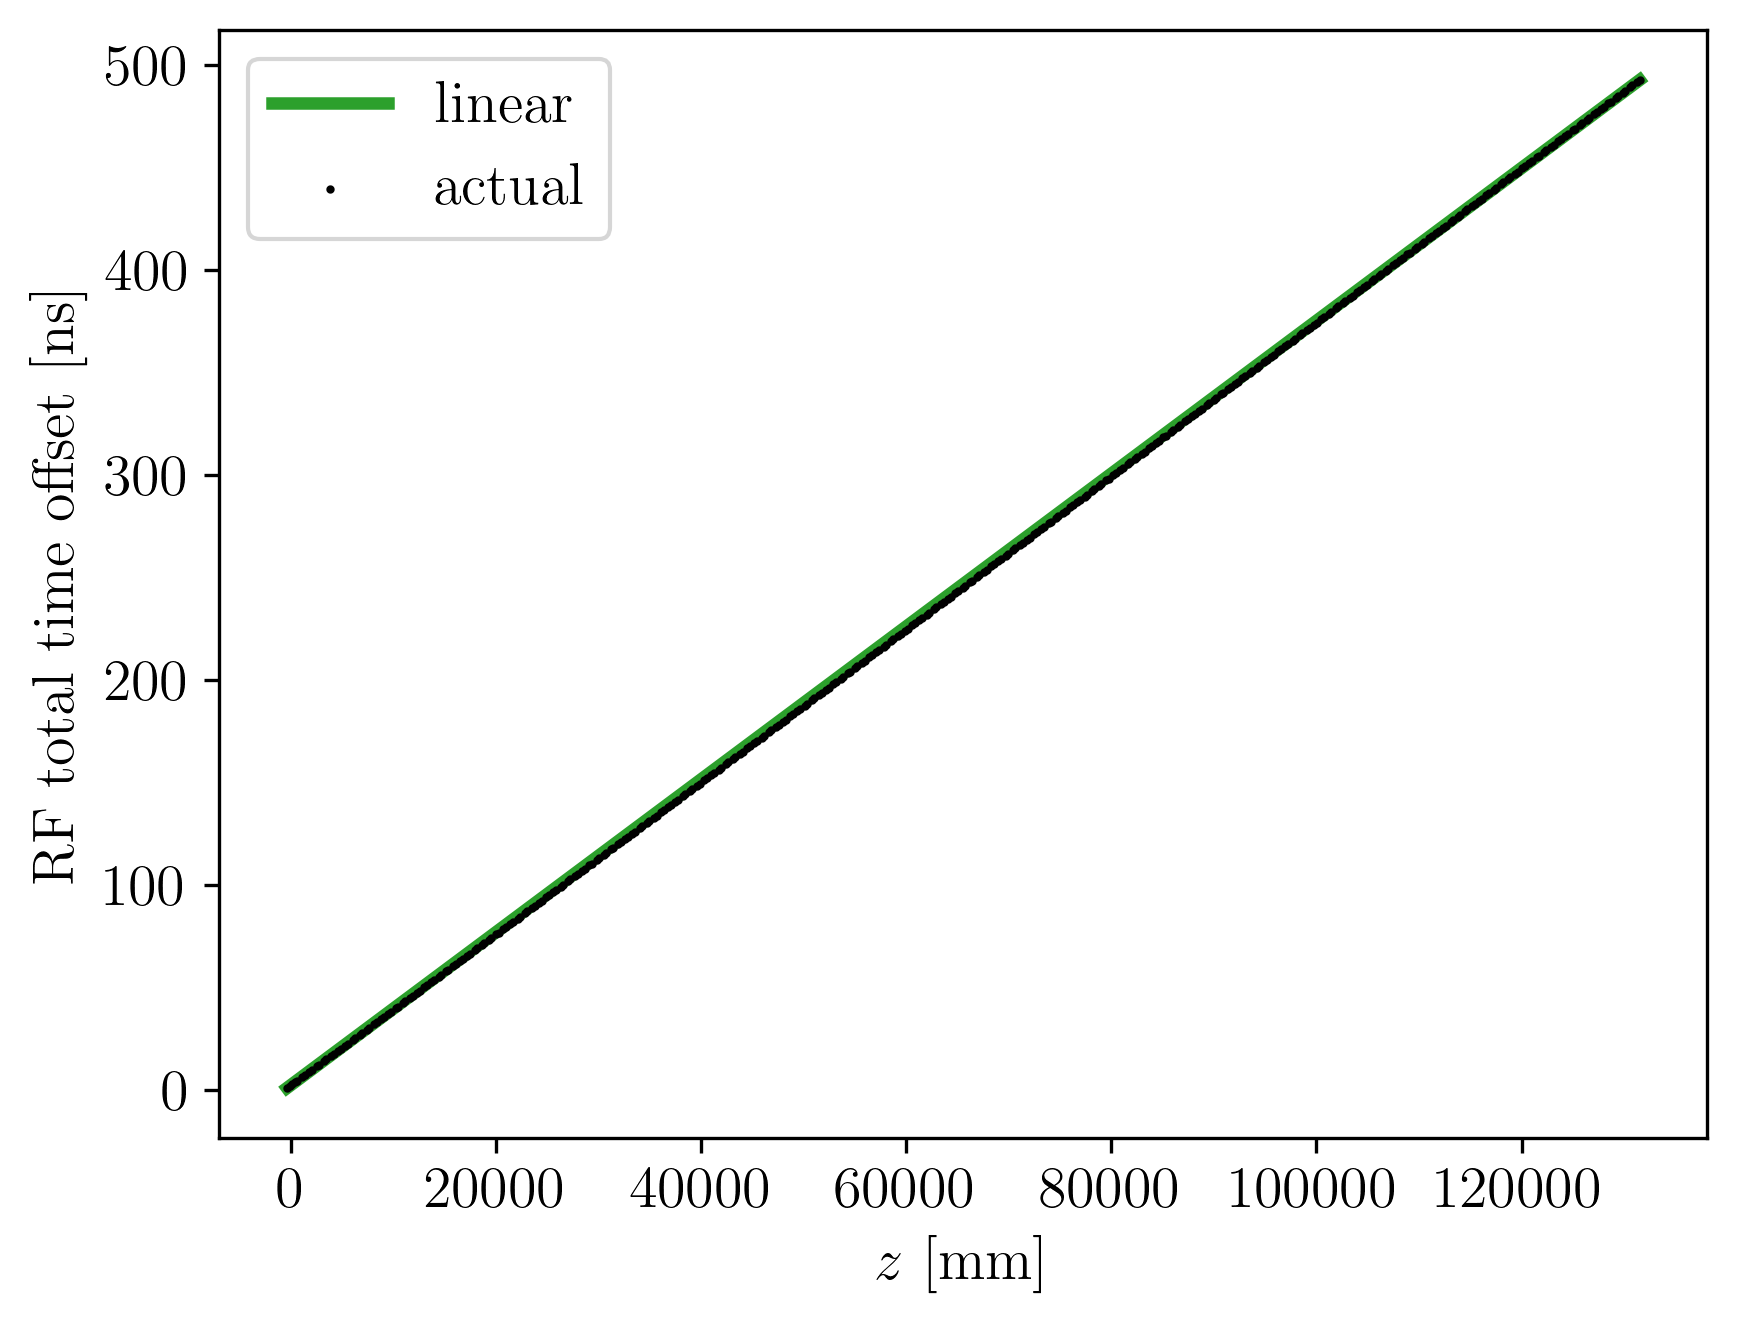

In [252]:
plt.plot(zlin2,tlin2,color='tab:green',zorder=0,linewidth=3,label='linear')
plt.scatter(ttotal['z'],ttotal['t'],s=1,color='black',label='actual')
plt.xlabel('$z$ [mm]')
plt.ylabel('RF total time offset [ns]')
plt.legend();

In [253]:
# RF frequency:
fRF = 325e6 # Hz
# RF period:
TRF = 1/fRF*10**9 # ns

In [254]:
modvals = []
for i in range(len(ttotal['t'])):
    modvals.append(ttotal['t'][i] % TRF)

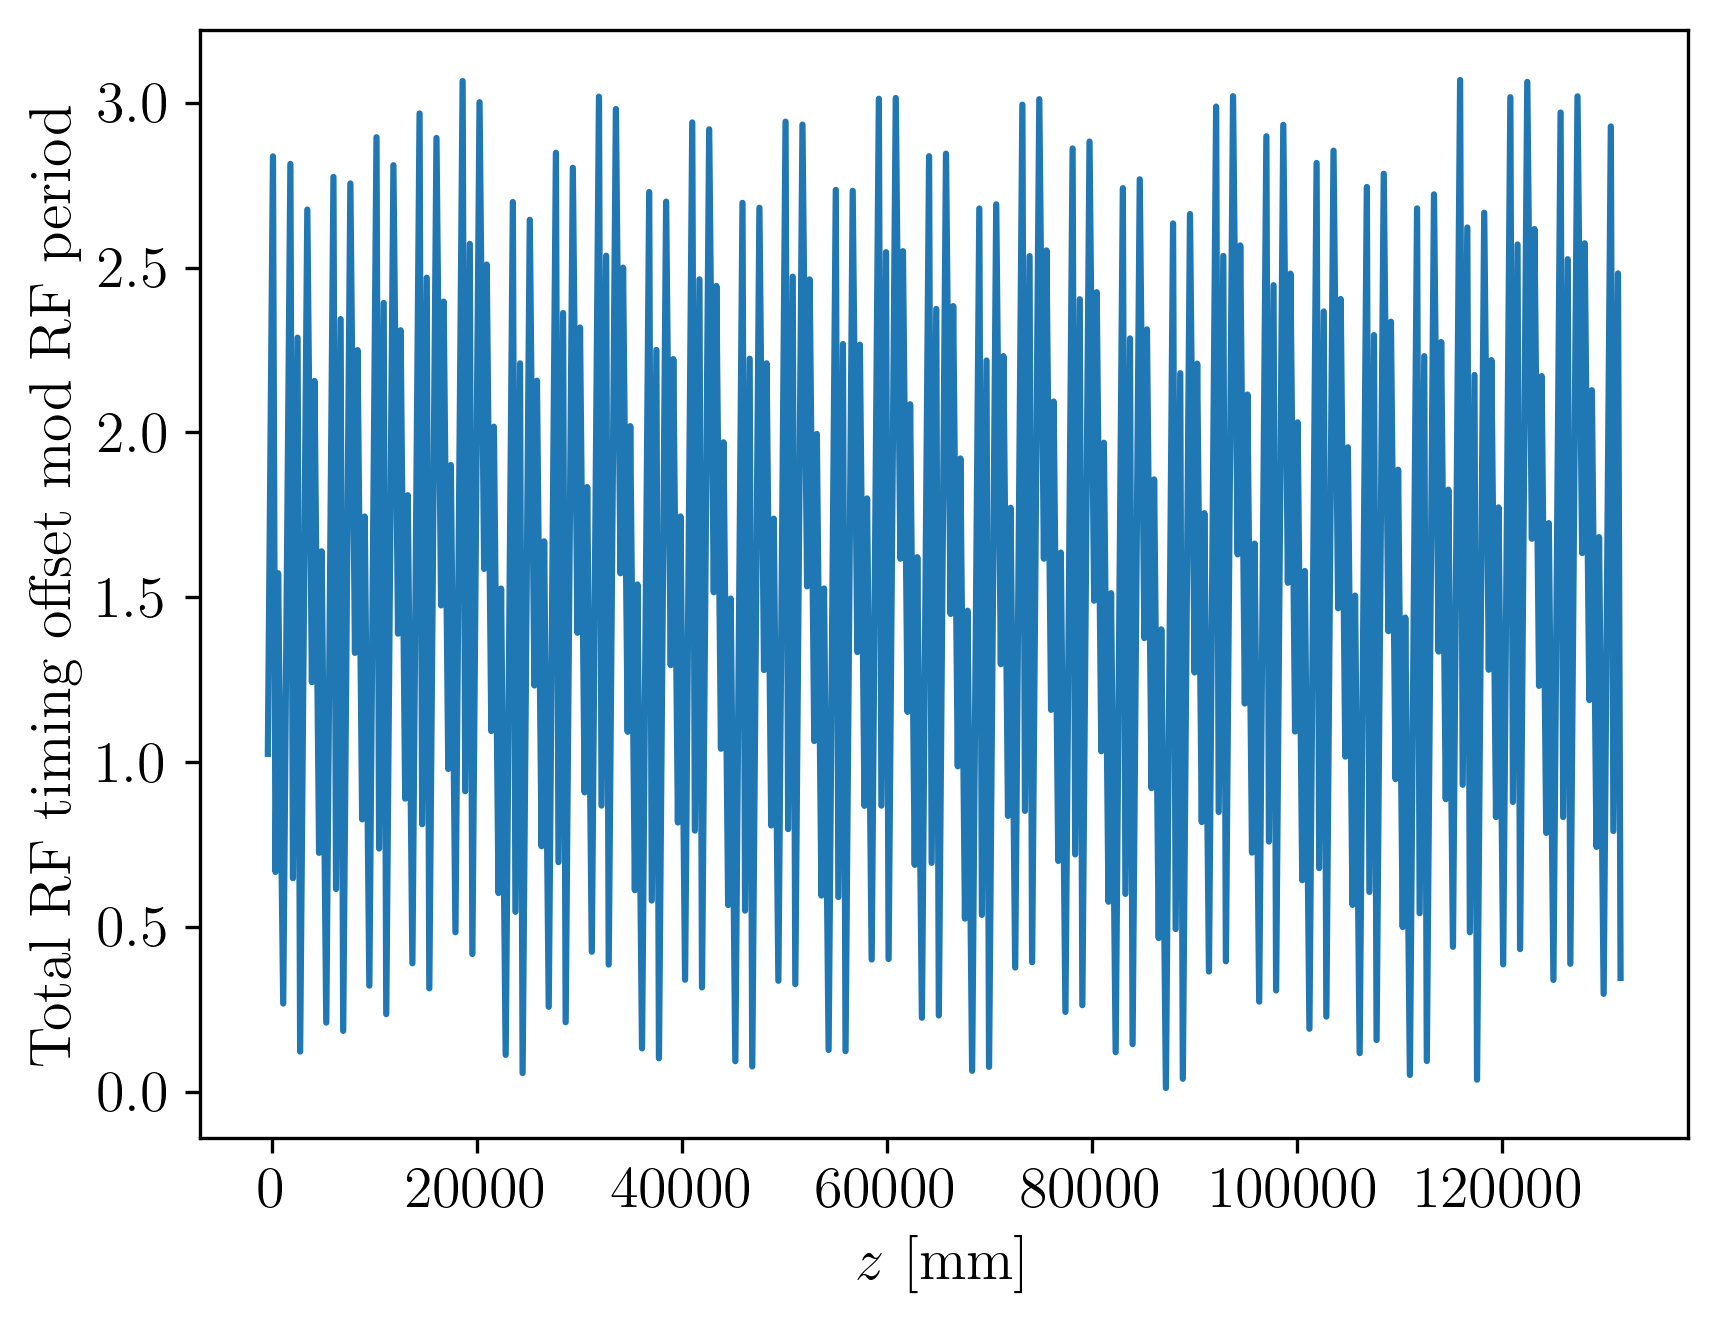

In [255]:
# plt.scatter(ttotal['z'], modvals, s=2, color='black')
plt.plot(ttotal['z'], modvals)
plt.xlabel('$z$ [mm]')
plt.ylabel('Total RF timing offset mod RF period');

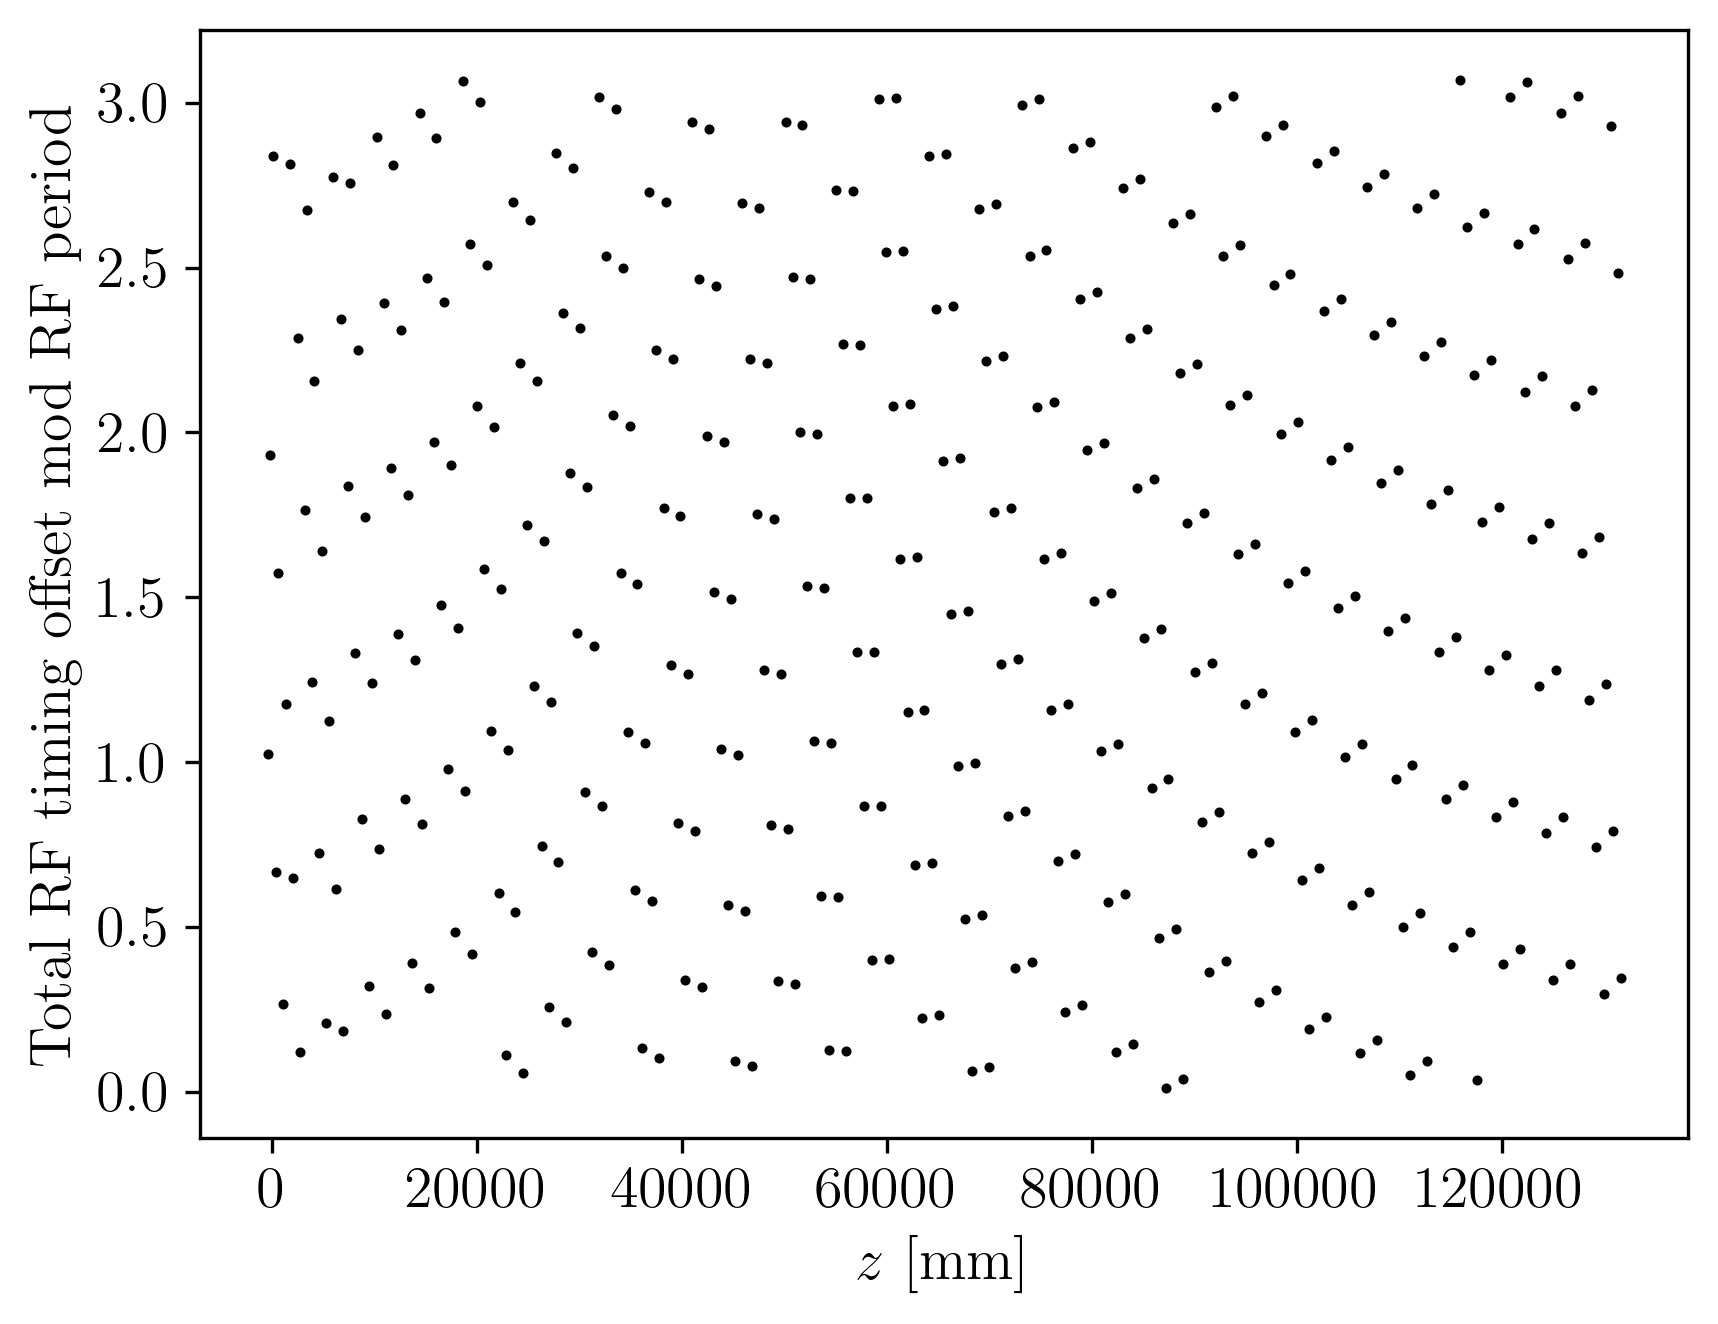

In [256]:
f = 325*10**6 # MHz
T = 1/f*10**9 # ns
plt.scatter(ttotal['z'], ttotal['t'] % T, s=2, color='black')
plt.xlabel('$z$ [mm]')
plt.ylabel('Total RF timing offset mod RF period');

In [257]:
tdiffs = []
for i in range(1,len(ttotal)):
    tdiffs.append(ttotal['t'][i]-ttotal['t'][i-1])

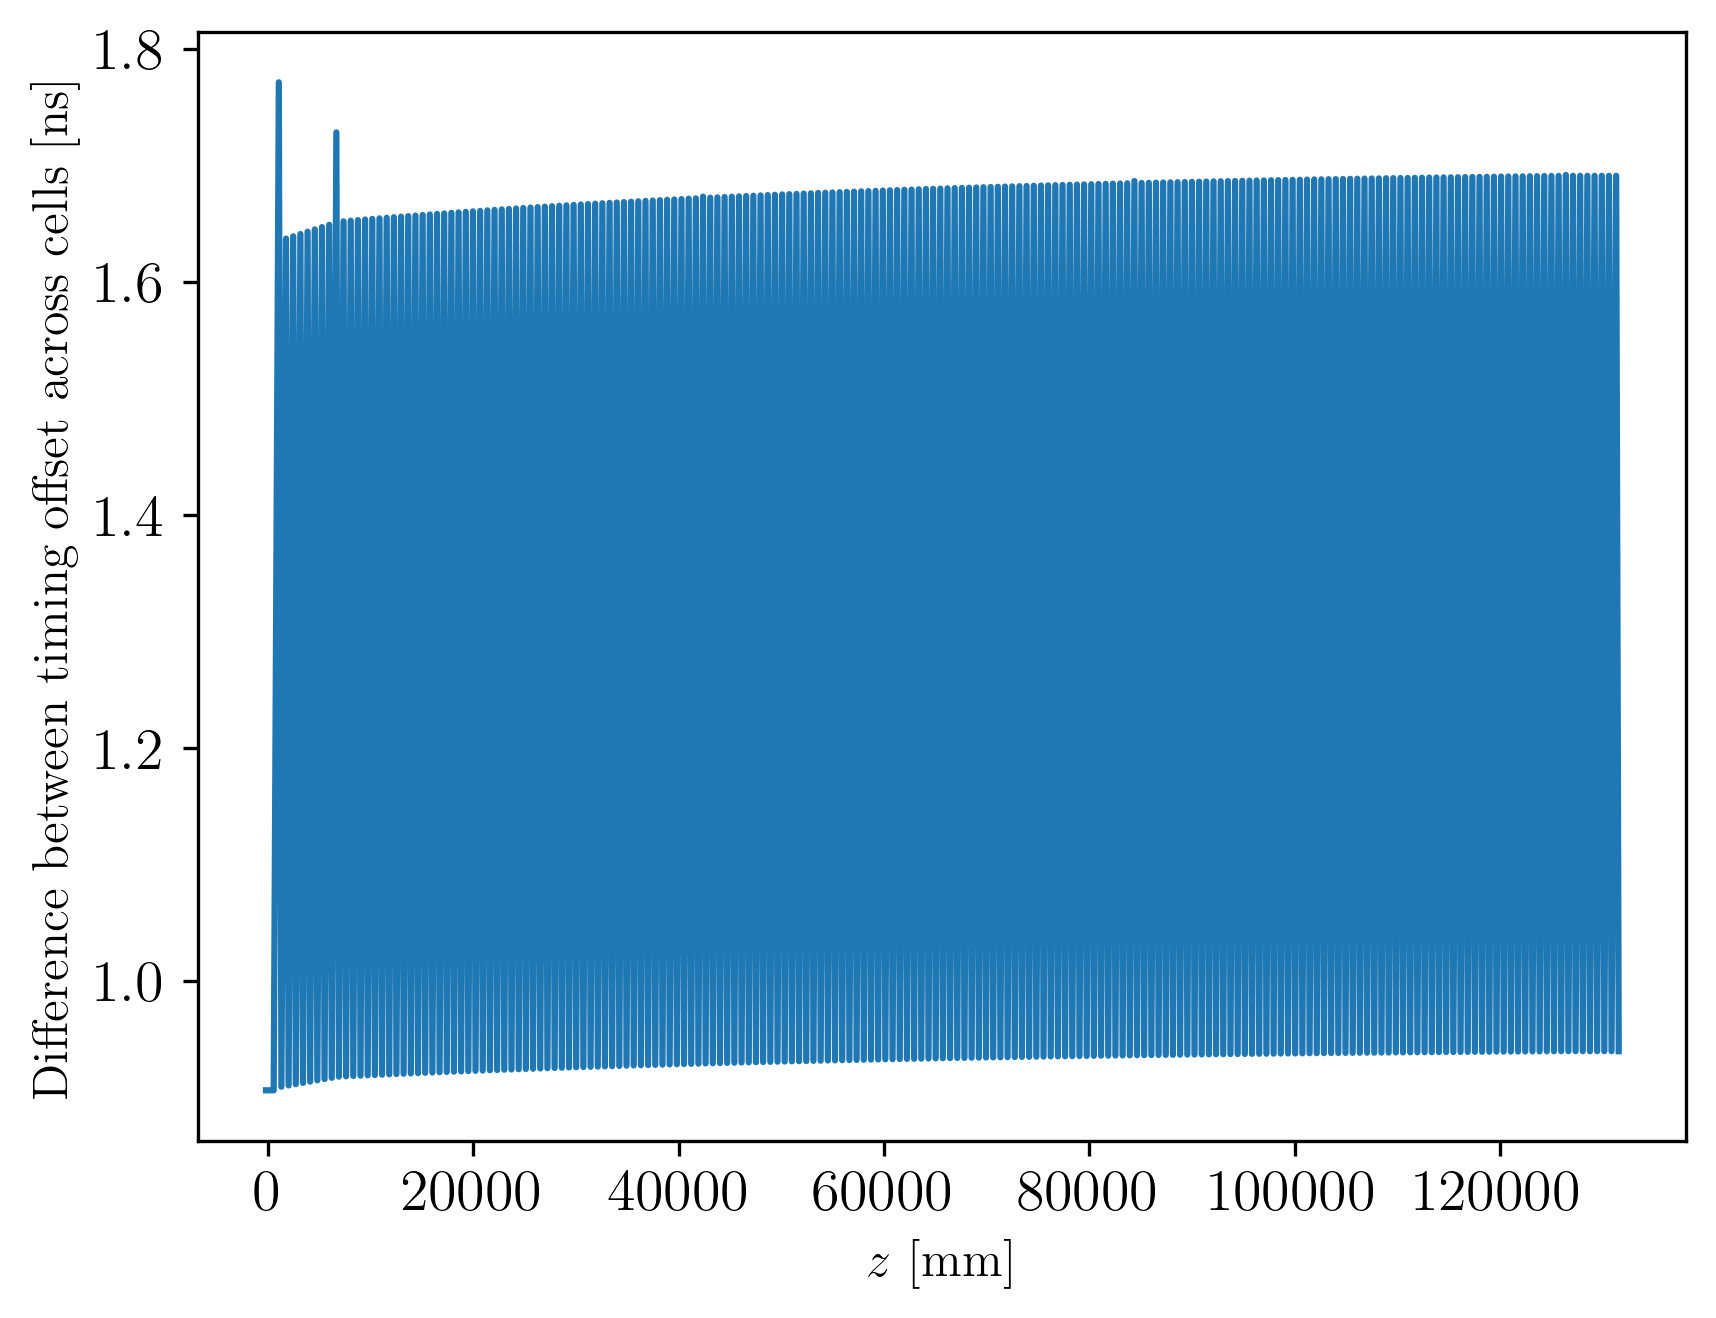

In [258]:
plt.plot(ttotal['z'][1:],tdiffs)
plt.xlabel('$z$ [mm]',fontsize=12)
plt.ylabel('Difference between timing offset across cells [ns]',fontsize=12);

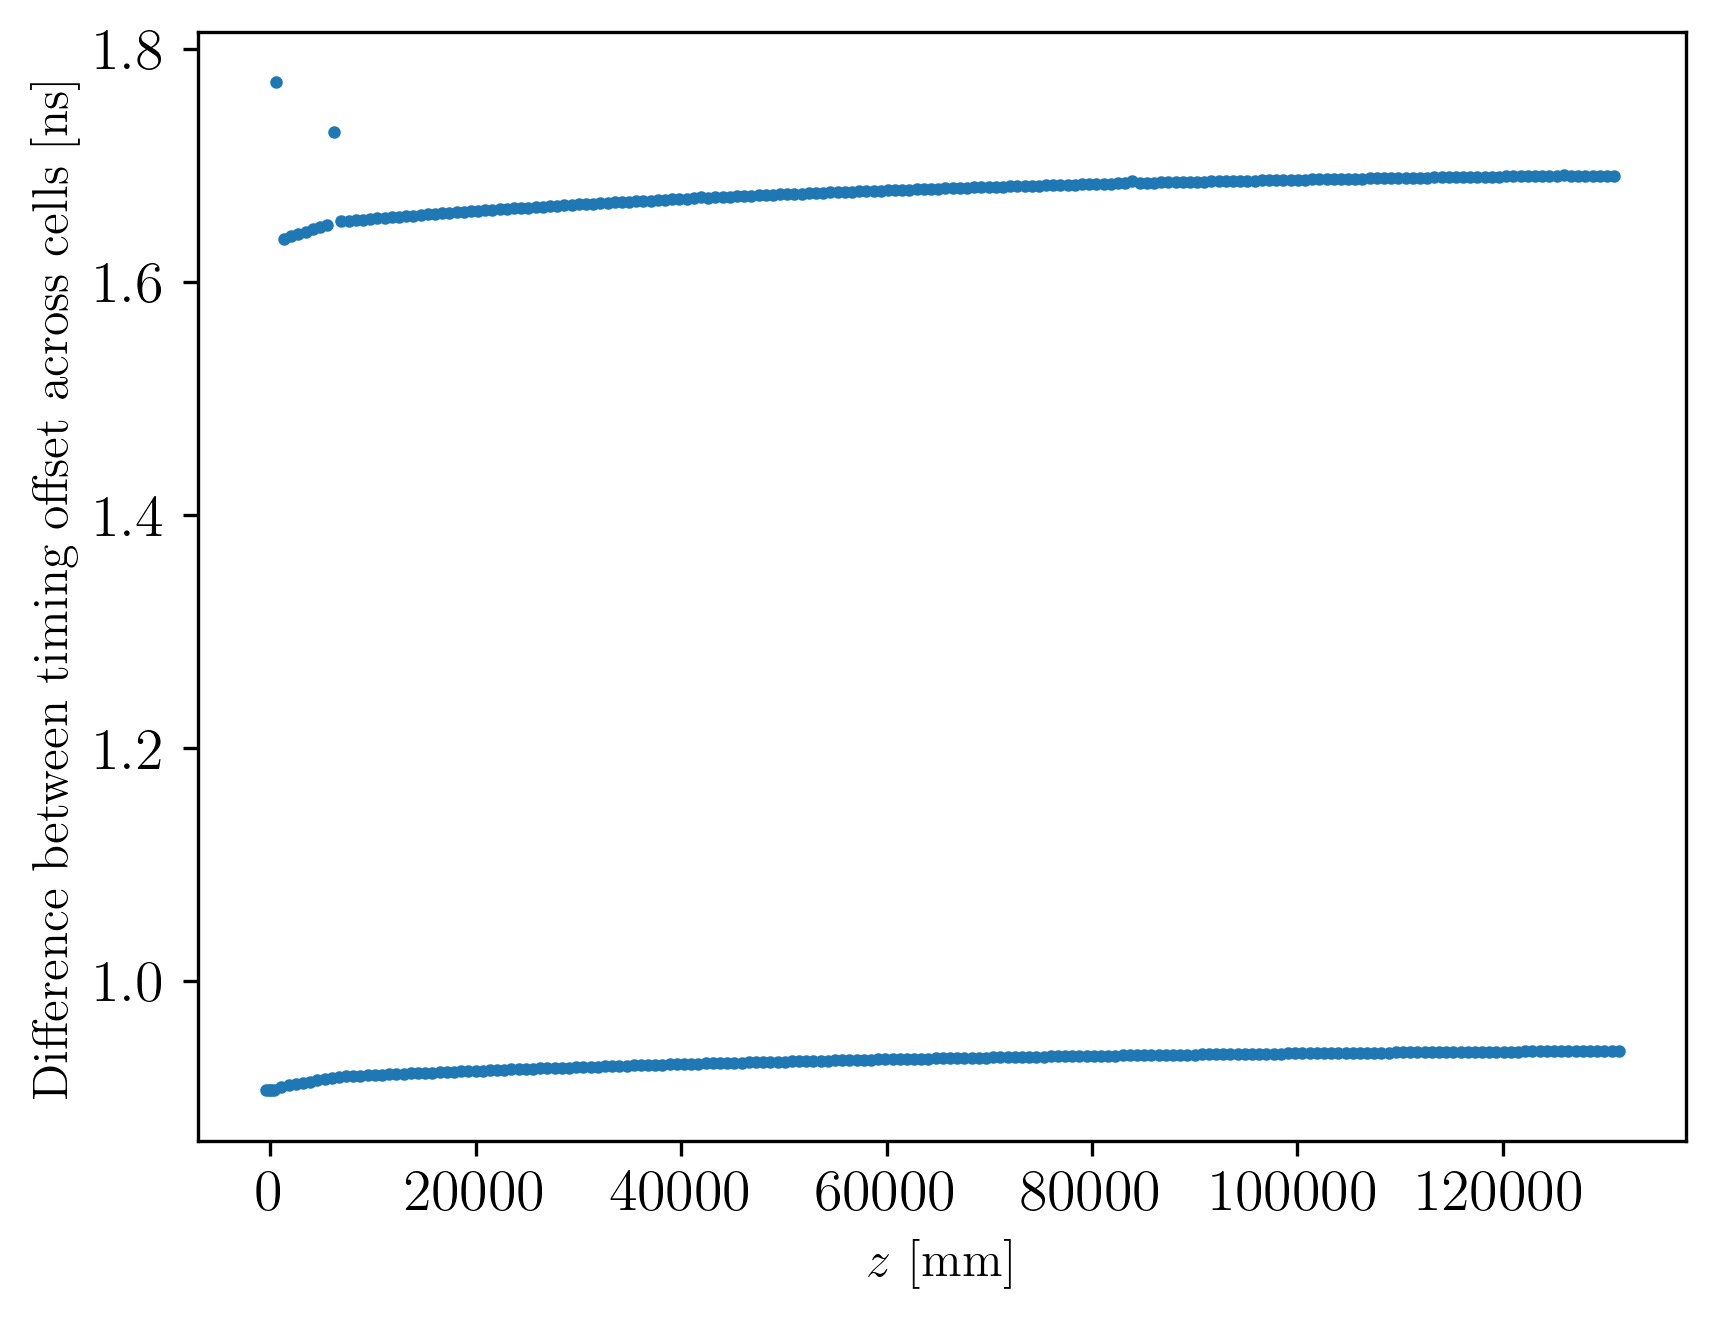

In [259]:
plt.scatter(ttotal['z'][:-1],tdiffs,s=4)
plt.xlabel('$z$ [mm]',fontsize=12)
plt.ylabel('Difference between timing offset across cells [ns]',fontsize=12);

Note: this is difference between current and previous cell (i.e. how much the timing offset has been changed w.r.t. to the previous value)

In [260]:
zdiffs = []
for i in range(1,len(ttotal)):
    zdiffs.append(ttotal['z'][i]-ttotal['z'][i-1])

In [261]:
zdiffs

[np.float64(250.0),
 np.float64(250.0),
 np.float64(250.0),
 np.float64(250.0),
 np.float64(500.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),
 np.float64(450.0),
 np.float64(250.0),


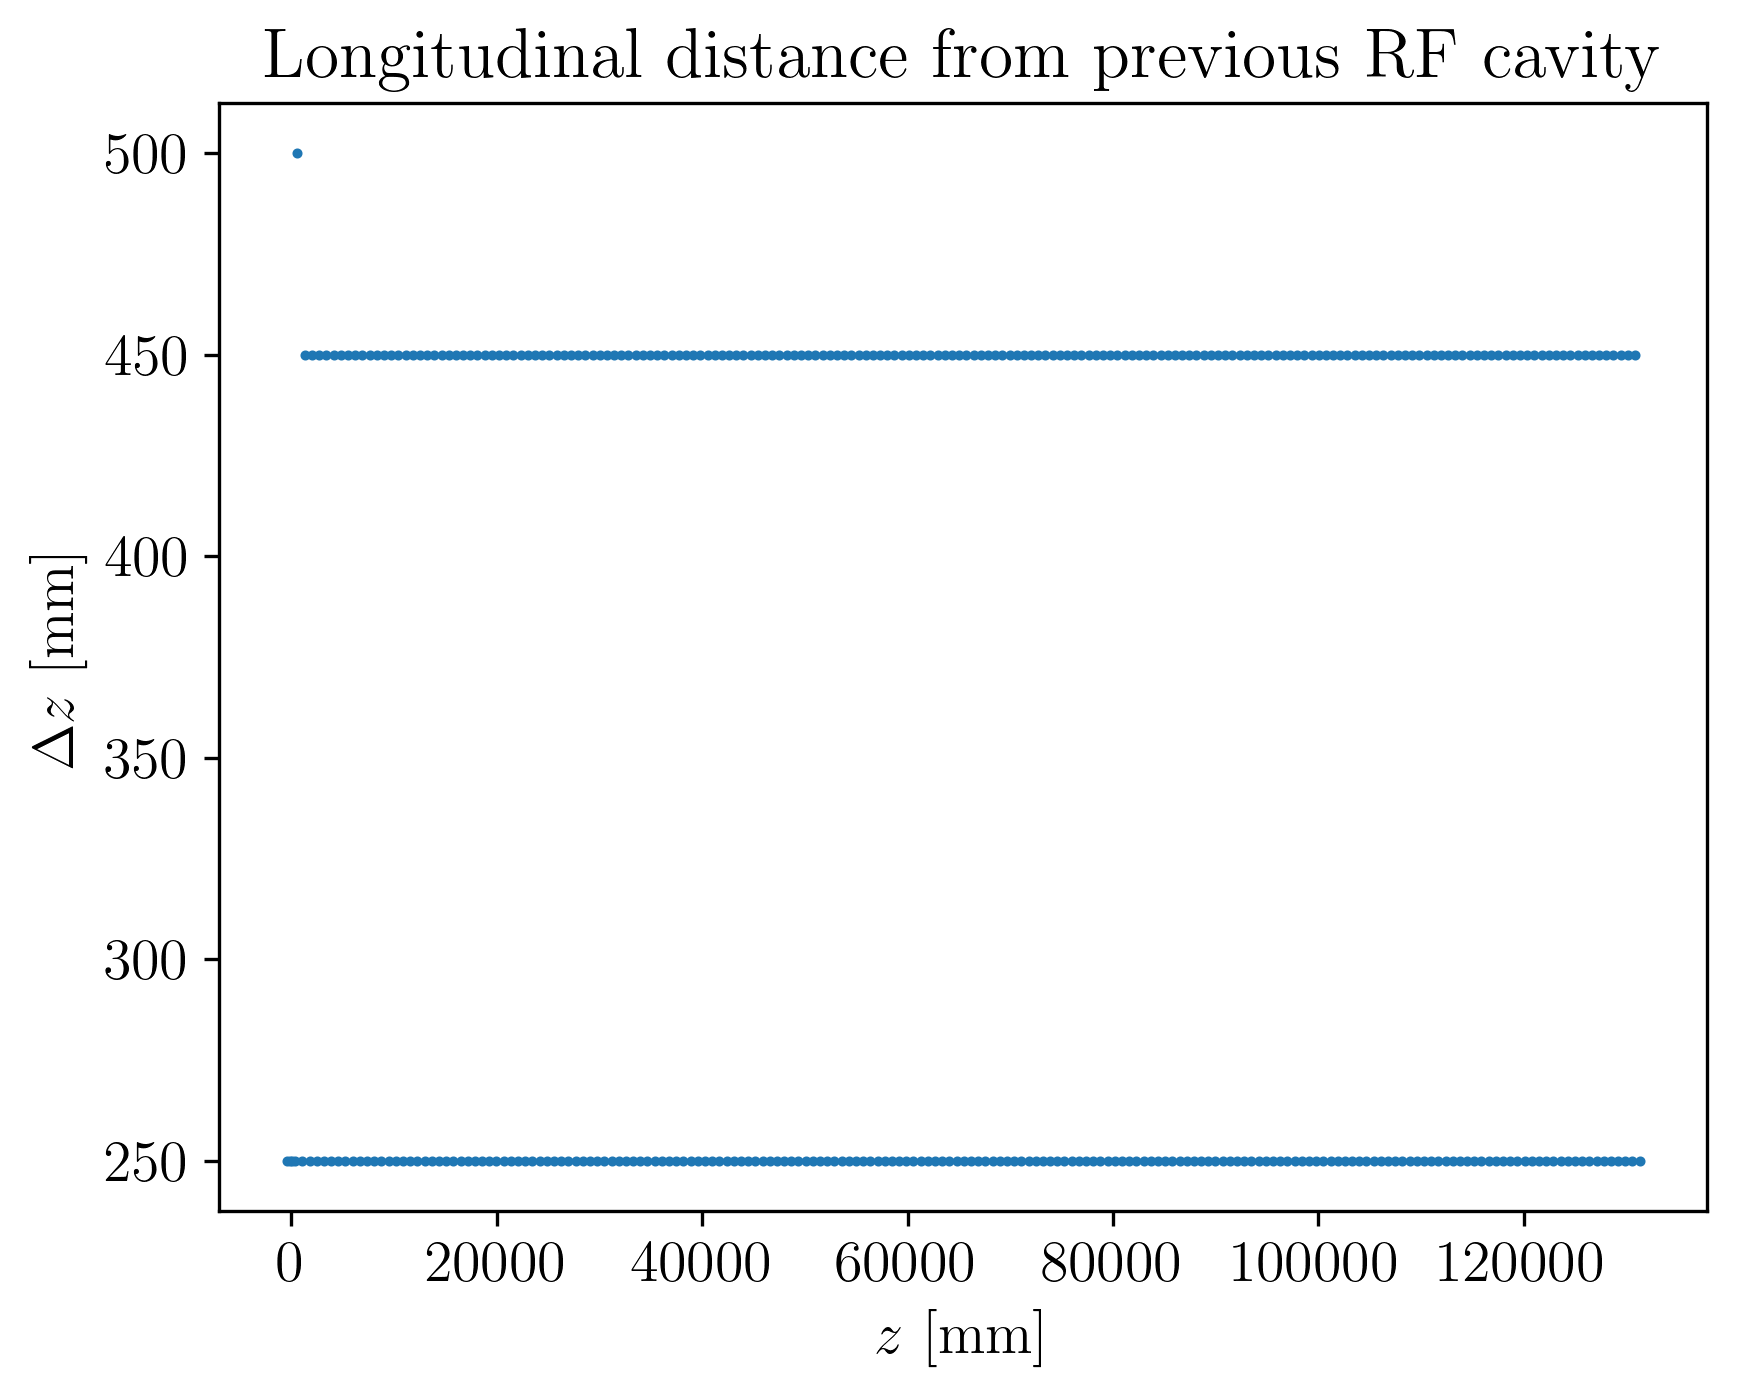

In [262]:
plt.scatter(ttotal['z'][:-1],zdiffs,s=2)
plt.ylabel('$\Delta z$ [mm]')
plt.xlabel('$z$ [mm]')
plt.title('Longitudinal distance from previous RF cavity');

Note: from center to center

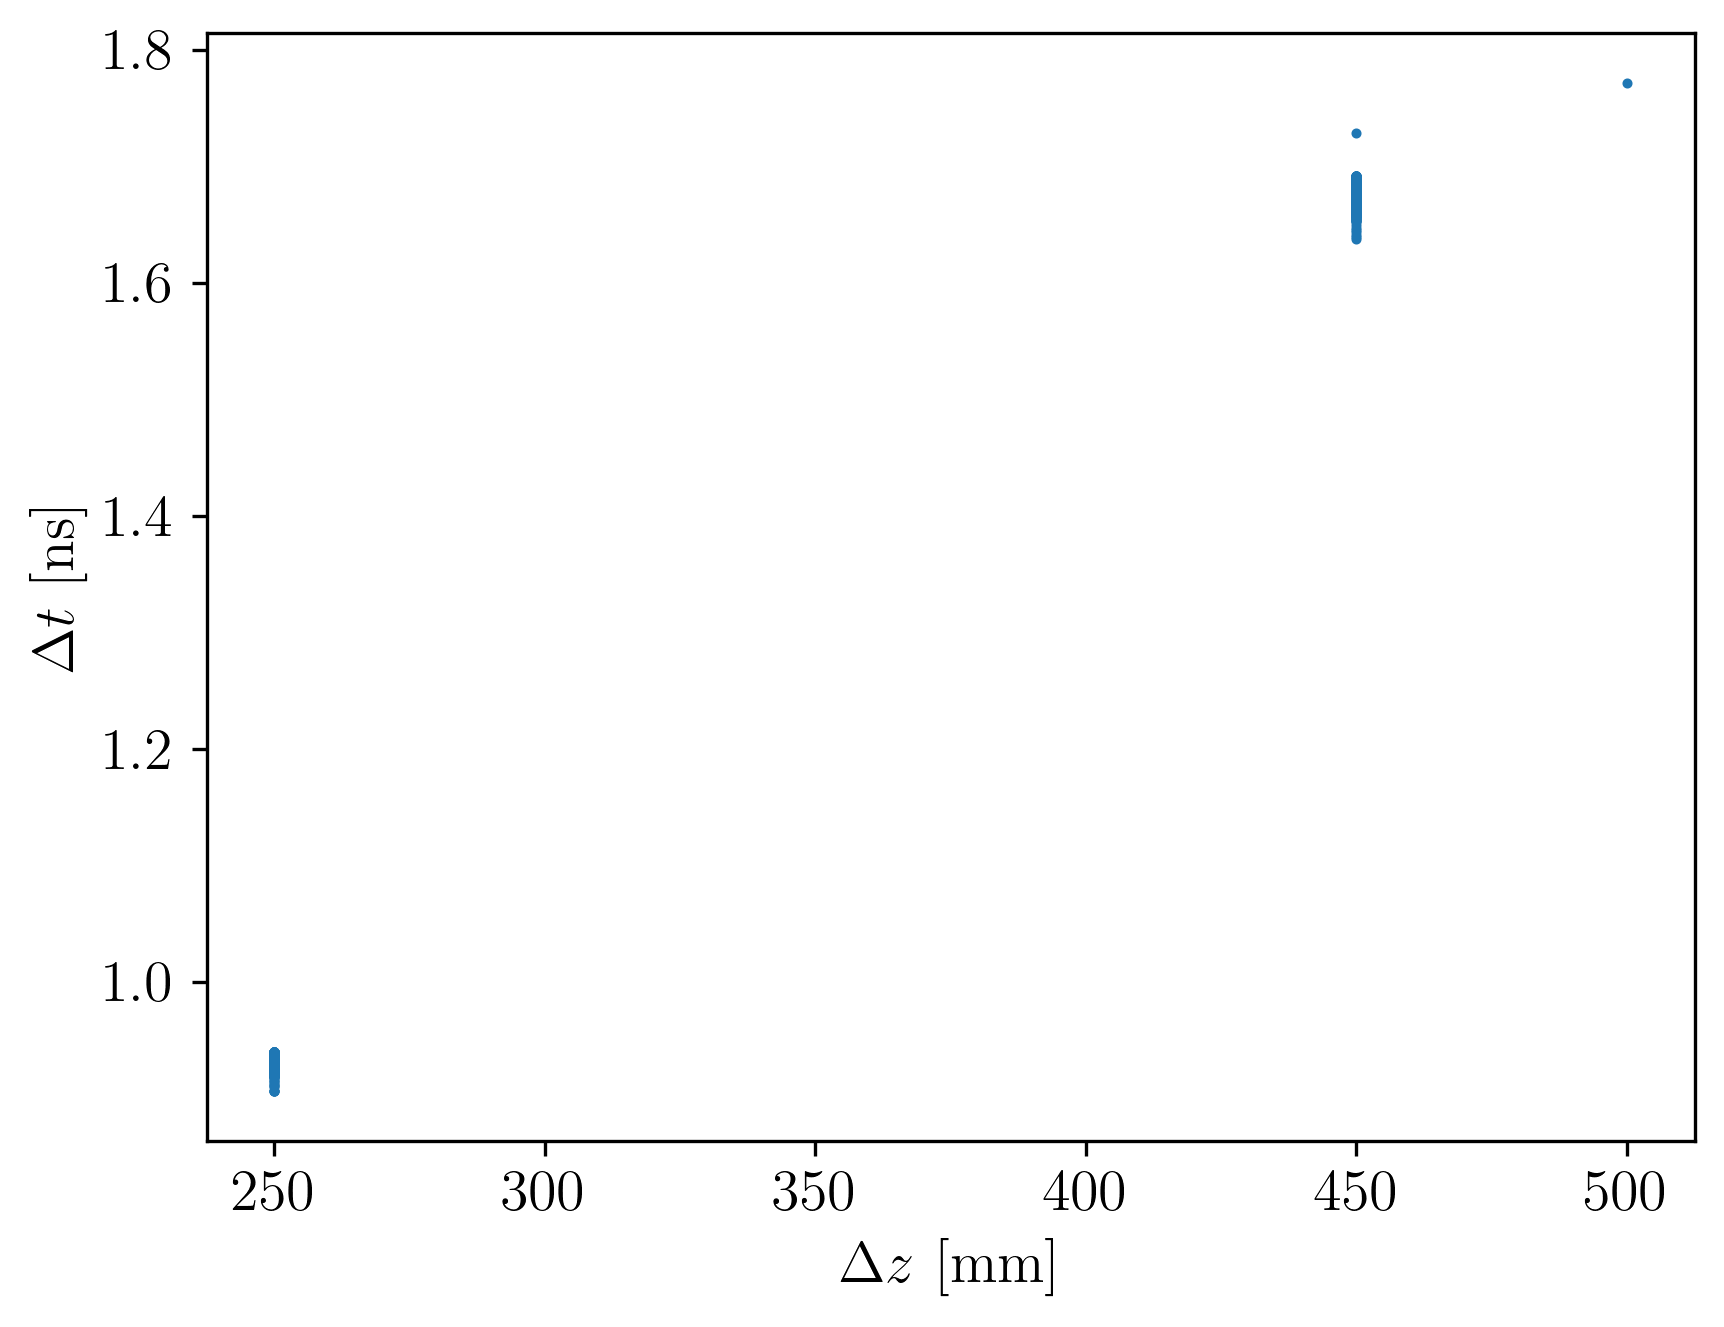

In [263]:
plt.scatter(zdiffs,tdiffs,s=2)
plt.xlabel('$\Delta z$ [mm]')
plt.ylabel('$\Delta t$ [ns]');

In [265]:
vs = []
for i in range(len(tdiffs)):
    vs.append(zdiffs[i]/tdiffs[i]*10**6 ) # mm/ns --> m/s

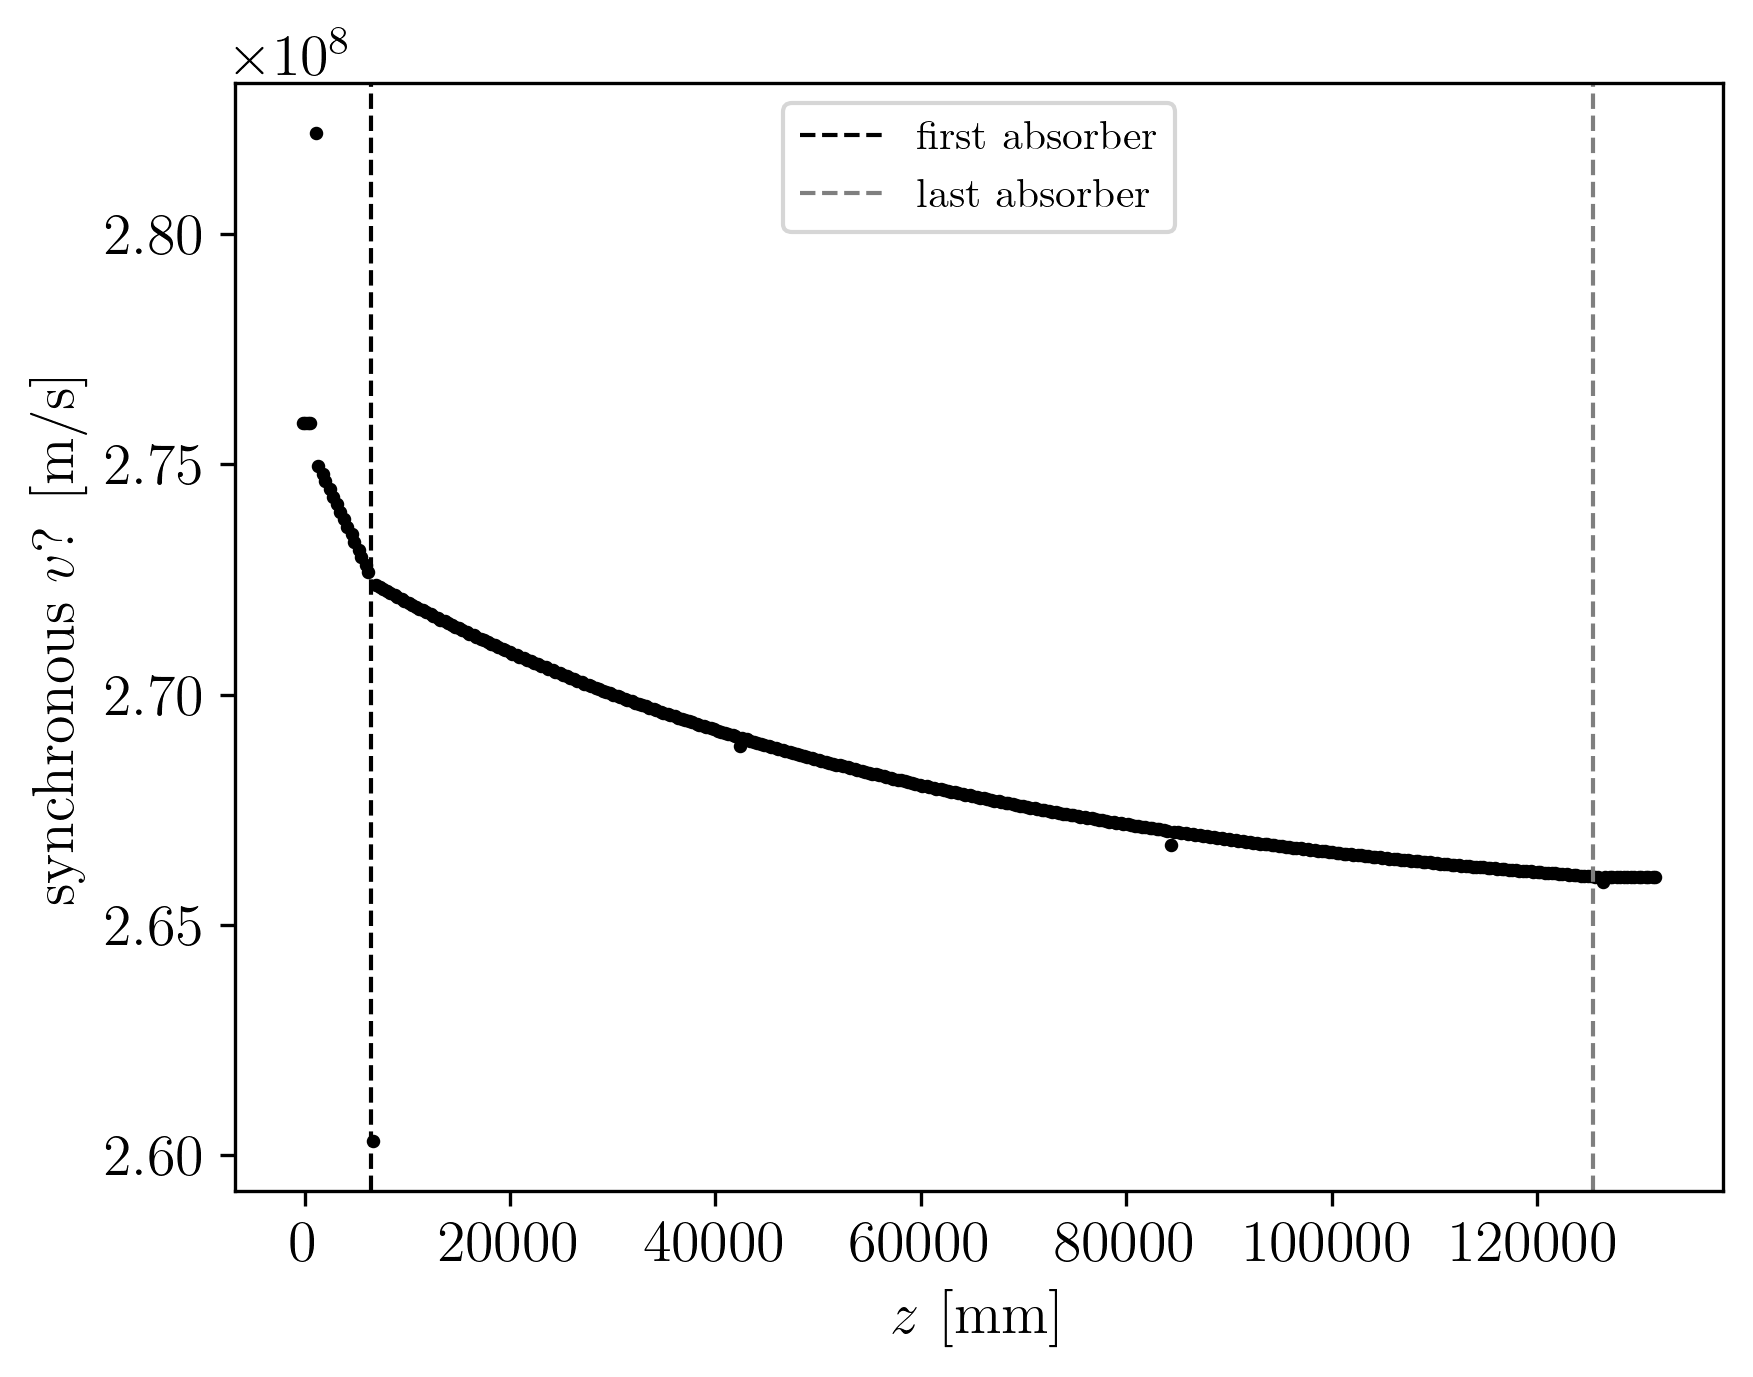

In [267]:
zvals = toffs['z'].values[1:]
plt.scatter(zvals,vs,s=5,color='black')
plt.axvline(zabsi,label='first absorber',color='black',linestyle='--',linewidth=1)
plt.axvline(zabsf,label='last absorber',color='tab:gray',linestyle='--',linewidth=1)
plt.xlabel('$z$ [mm]')
plt.ylabel('synchronous $v$? [m/s]')
plt.legend(loc='upper center',fontsize=10);

define z as arrival z

first RFC0 at z = -425 mm

first RFC at z = 1075 mm

frist RFC1 at z = 42375 mm

first RFC2 at z = 84375 mm

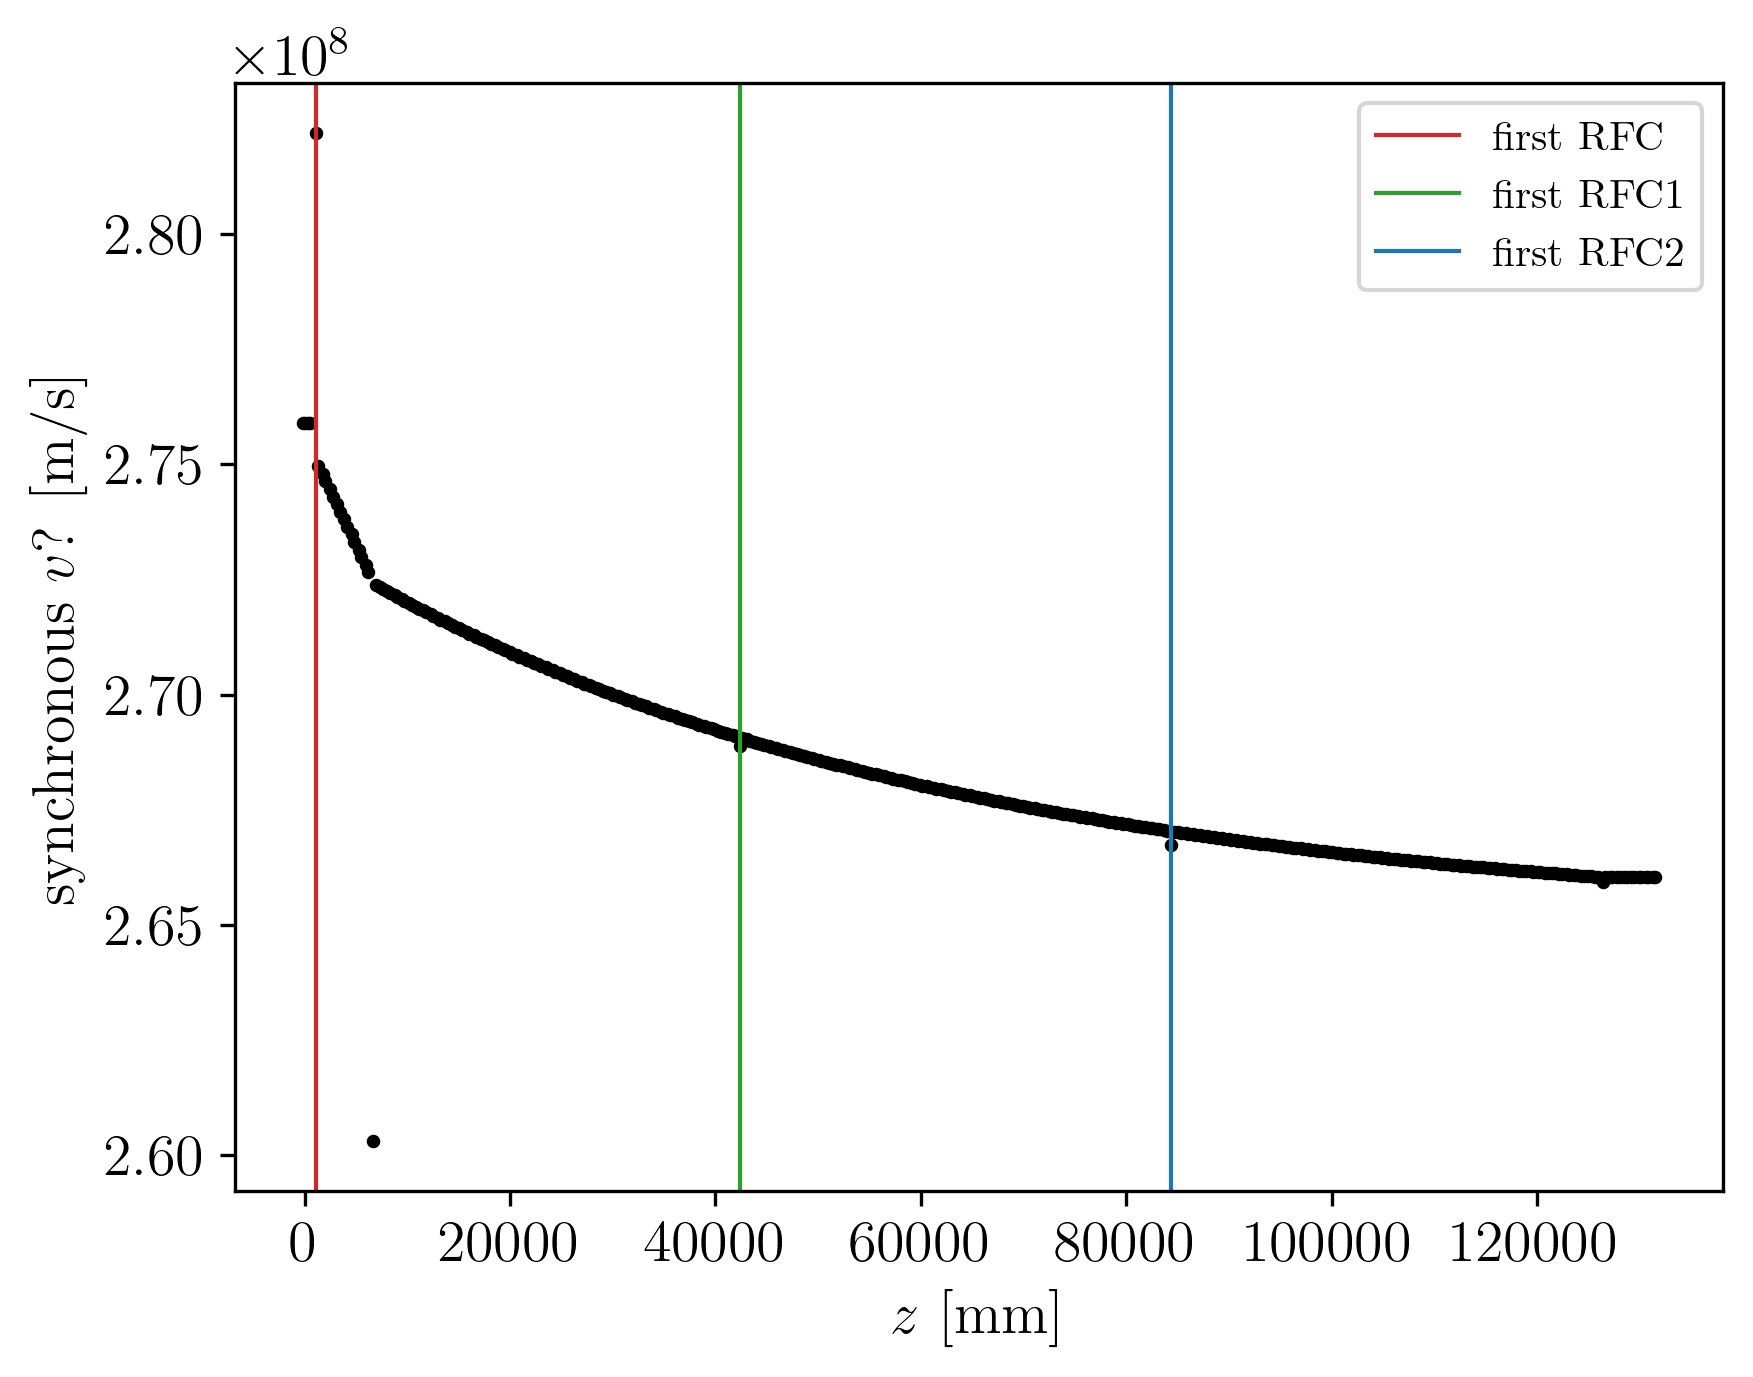

In [268]:
zvals = toffs['z'].values[1:]
plt.scatter(zvals,vs,s=5,color='black')
plt.axvline(1075,label='first RFC',color='tab:red',linewidth=1)
plt.axvline(42375,label='first RFC1',color='tab:green',linewidth=1)
plt.axvline(84375,label='first RFC2',color='tab:blue',linewidth=1)
plt.xlabel('$z$ [mm]')
plt.ylabel('synchronous $v$? [m/s]')
plt.legend(loc='upper right',fontsize=10);

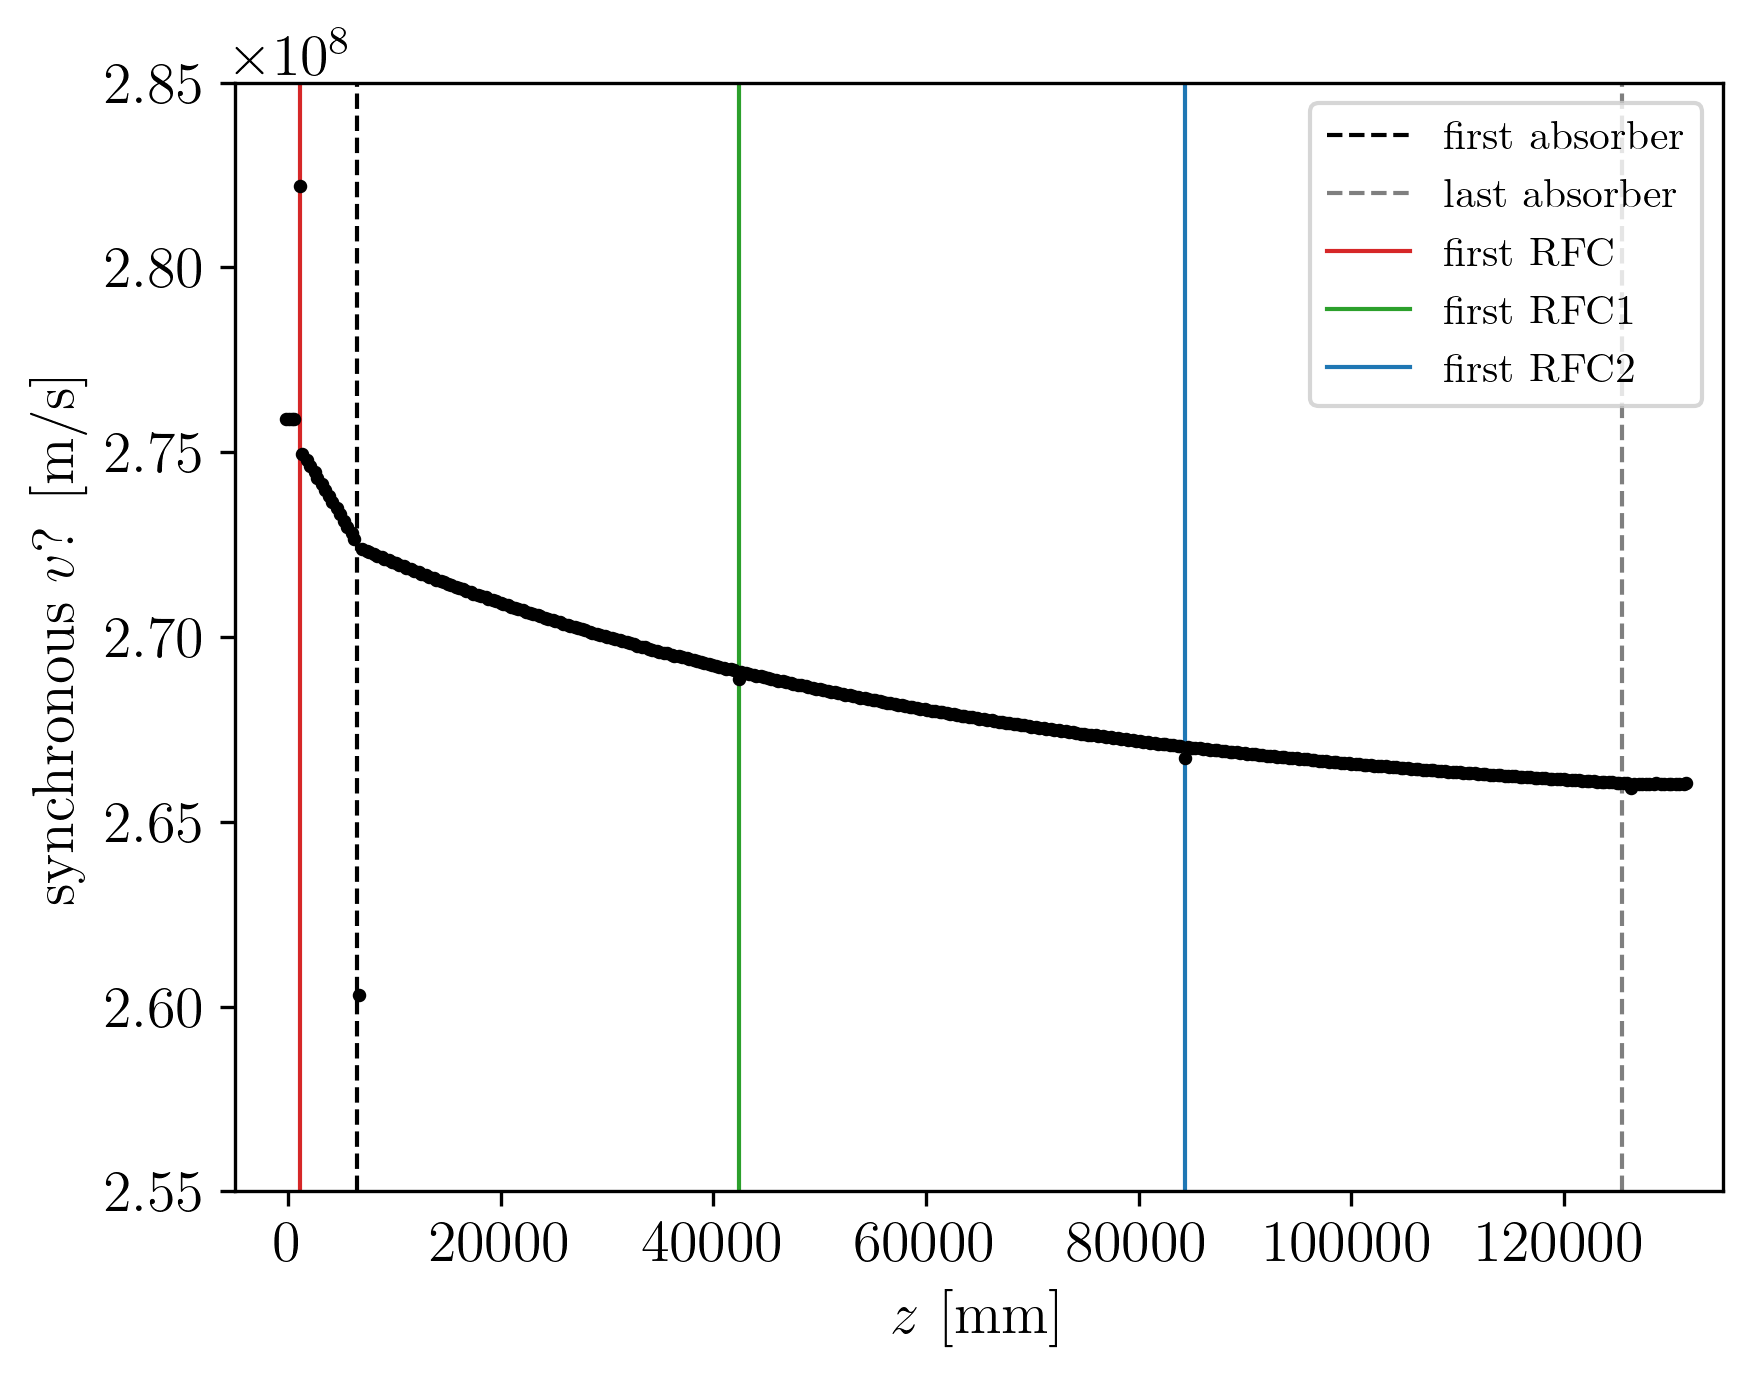

In [300]:
zvals = toffs['z'].values[1:]
plt.scatter(zvals,vs,s=5,color='black',zorder=10)
plt.axvline(zabsi,label='first absorber',color='black',linestyle='--',linewidth=1)
plt.axvline(zabsf,label='last absorber',color='tab:gray',linestyle='--',linewidth=1)
plt.axvline(1075,label='first RFC',color='tab:red',linewidth=1)
plt.axvline(42375,label='first RFC1',color='tab:green',linewidth=1)
plt.axvline(84375,label='first RFC2',color='tab:blue',linewidth=1)
plt.xlabel('$z$ [mm]')
plt.ylabel('synchronous $v$? [m/s]')
plt.ylim((2.55e8,2.85e8))
plt.xlim((-5000.0,135000.0))
plt.legend(loc='upper right',fontsize=10);

In [302]:
refv = v(221.8)

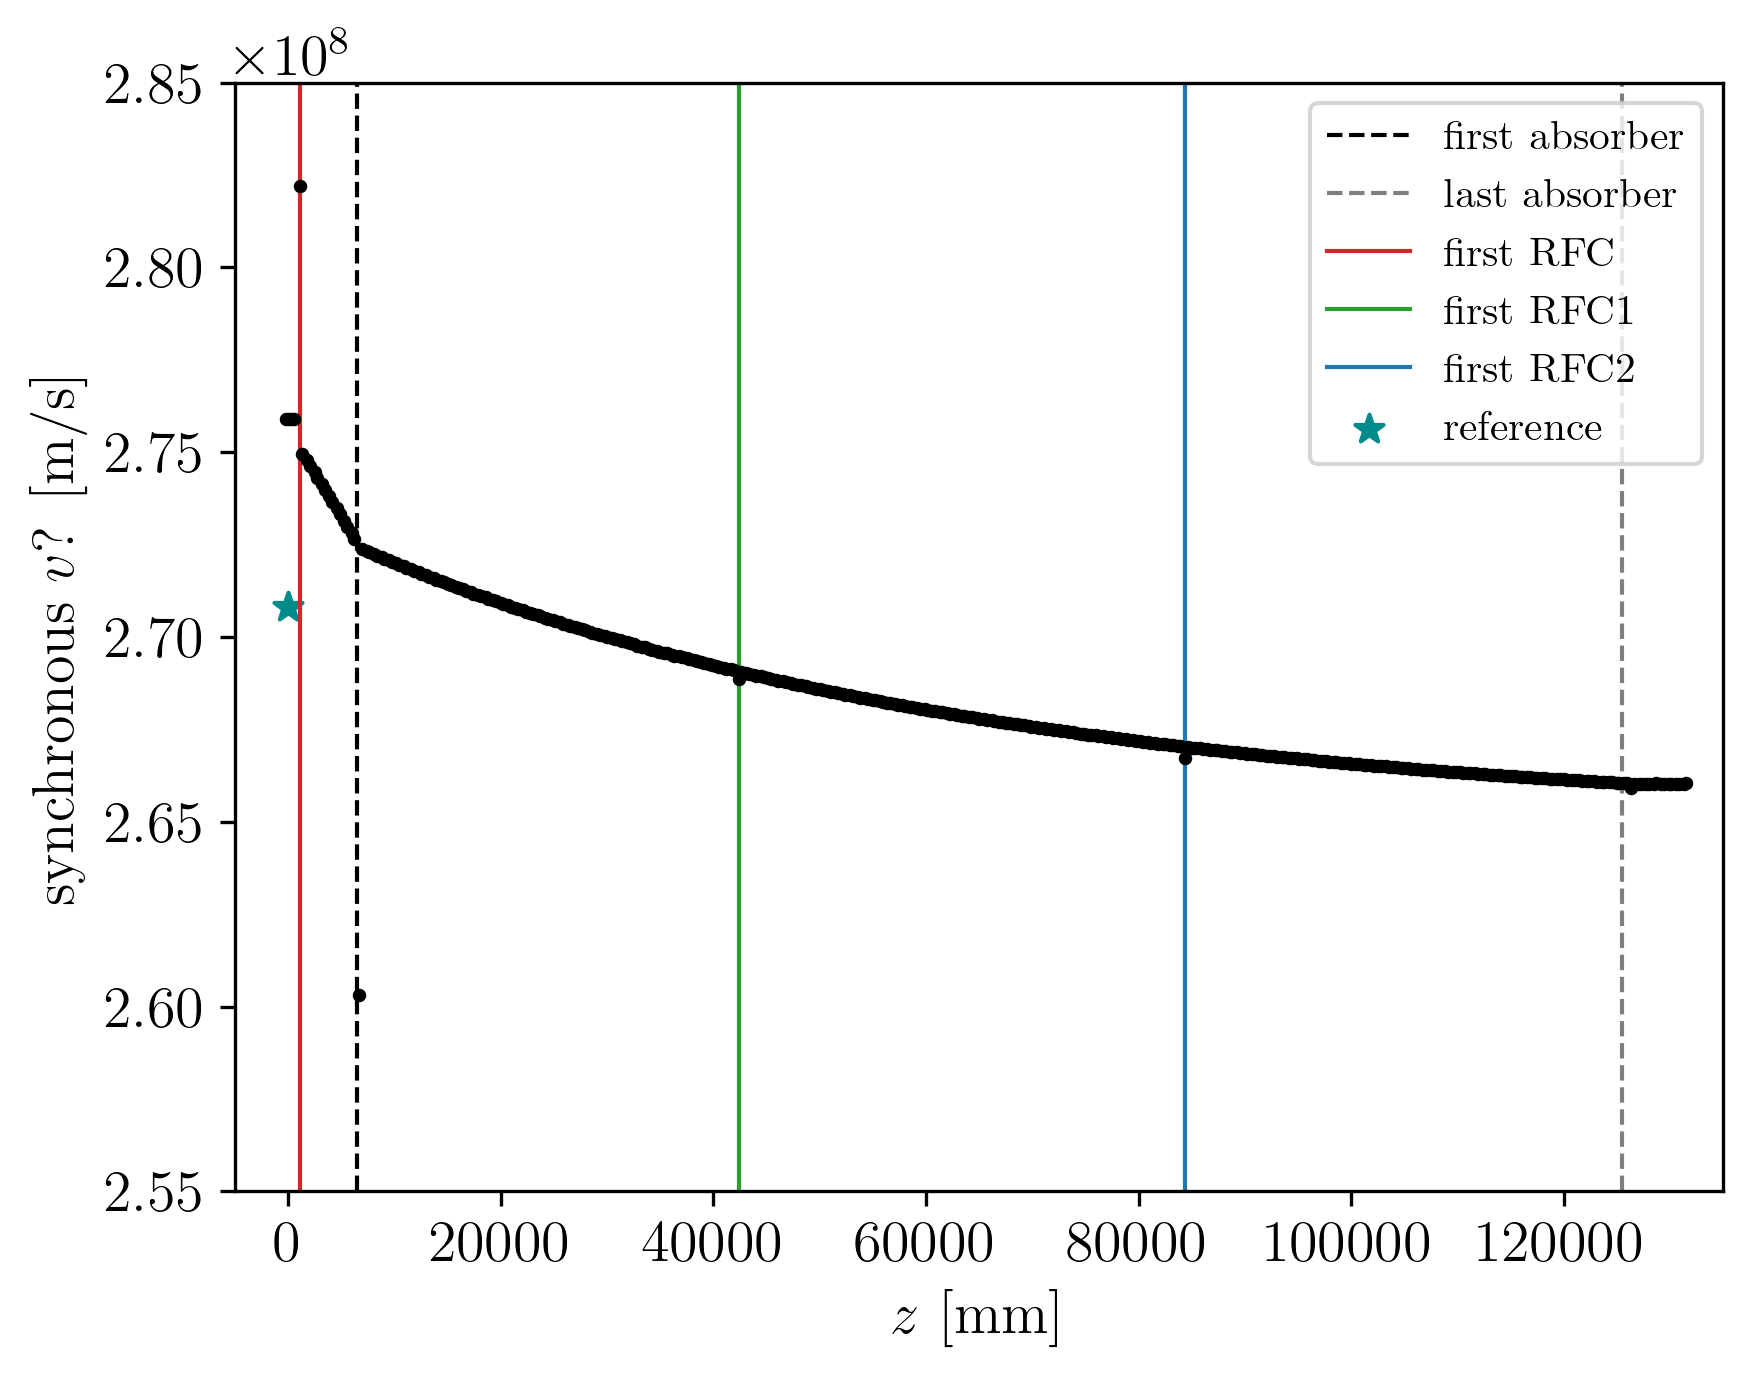

In [313]:
zvals = toffs['z'].values[1:]
plt.scatter(zvals,vs,s=5,color='black',zorder=10)
plt.axvline(zabsi,label='first absorber',color='black',linestyle='--',linewidth=1)
plt.axvline(zabsf,label='last absorber',color='tab:gray',linestyle='--',linewidth=1)
plt.axvline(1075,label='first RFC',color='tab:red',linewidth=1)
plt.axvline(42375,label='first RFC1',color='tab:green',linewidth=1)
plt.axvline(84375,label='first RFC2',color='tab:blue',linewidth=1)
plt.scatter(0,refv,color='darkcyan',marker='*',s=50,label='reference')
plt.xlabel('$z$ [mm]')
plt.ylabel('synchronous $v$? [m/s]')
plt.ylim((2.55e8,2.85e8))
plt.xlim((-5000.0,135000.0))
plt.legend(loc='upper right',fontsize=10);

In [316]:
beamstartv = v(247.5)

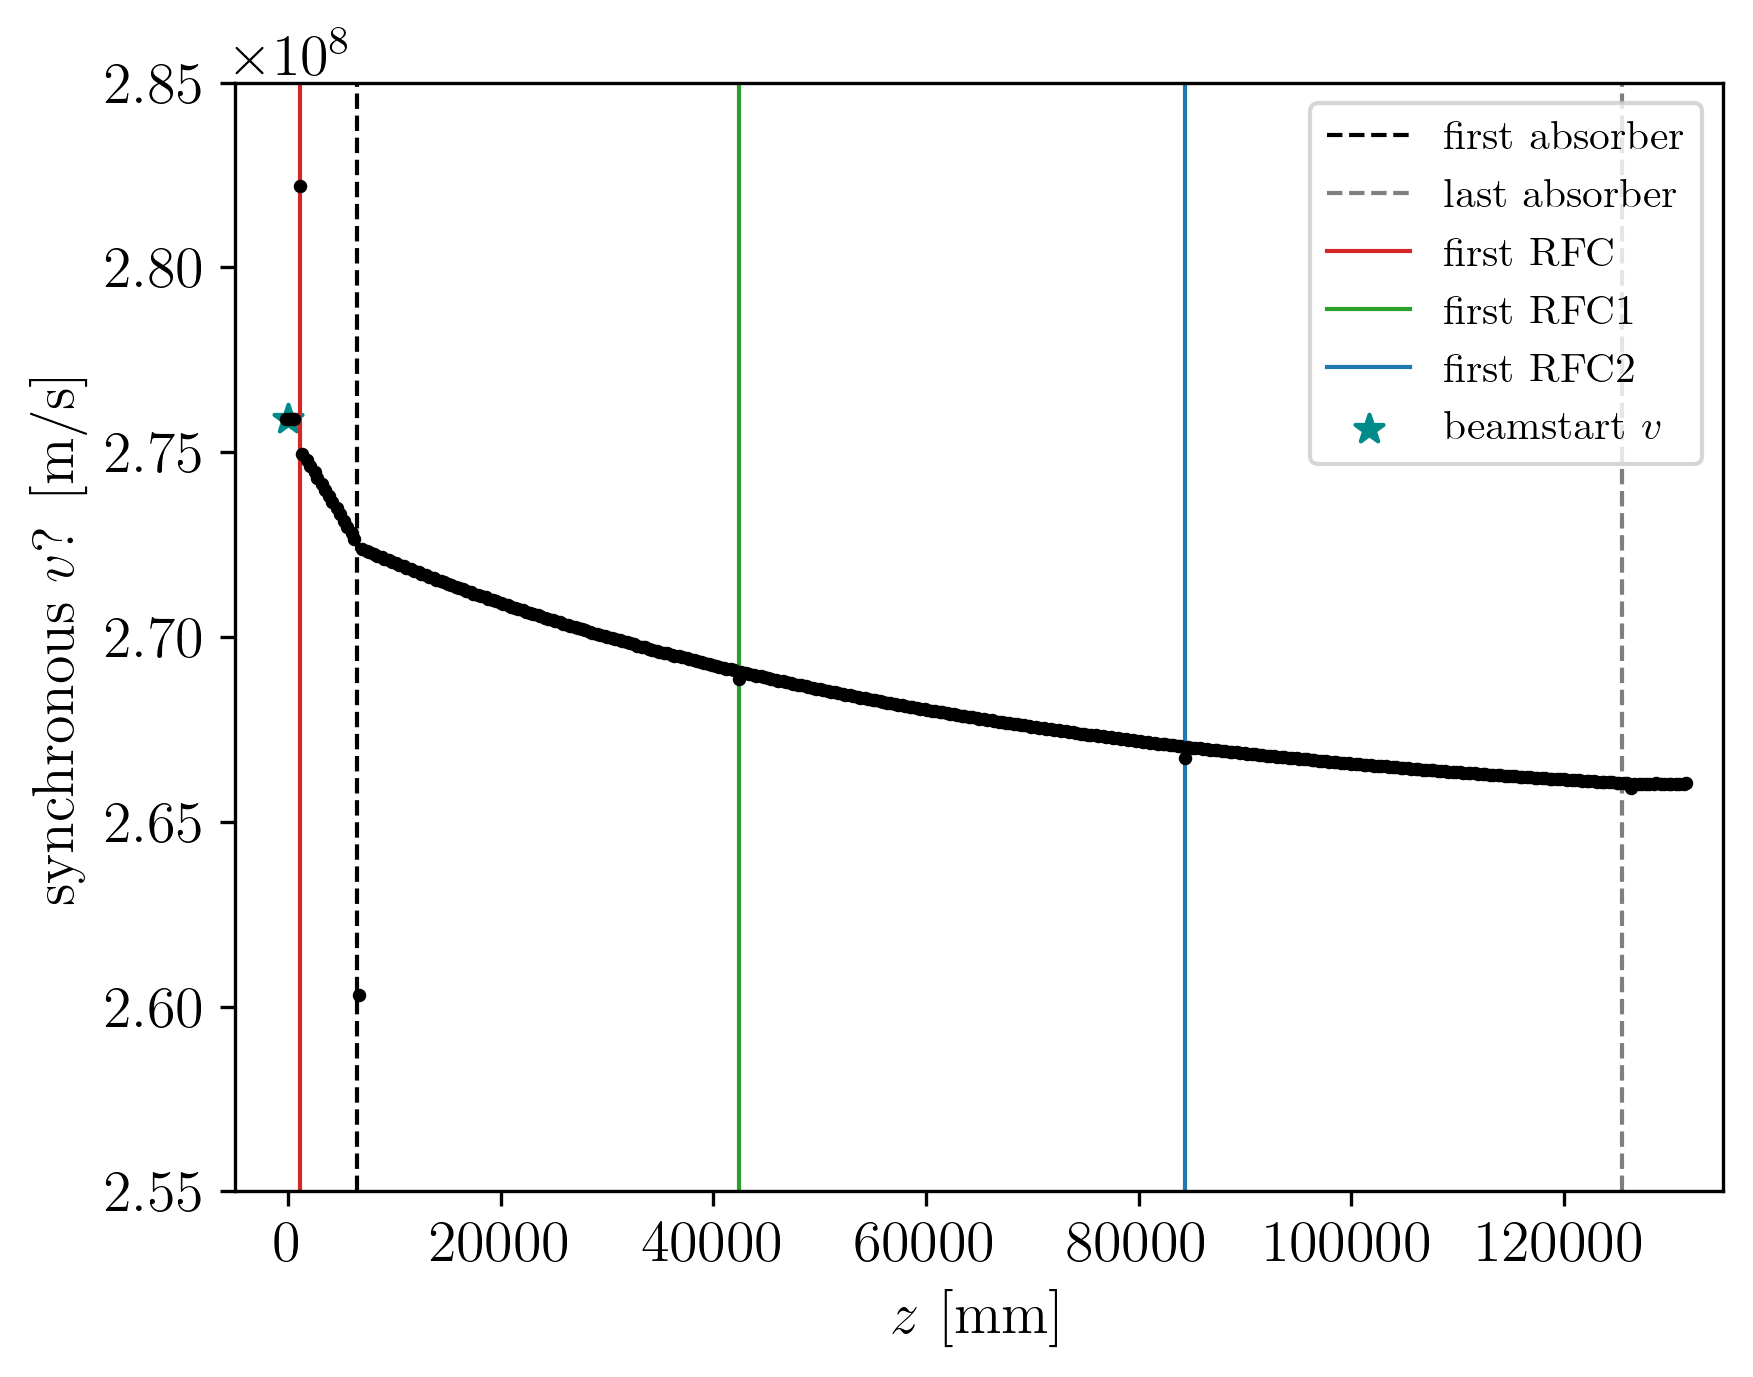

In [318]:
zvals = toffs['z'].values[1:]
plt.scatter(zvals,vs,s=5,color='black',zorder=10)
plt.axvline(zabsi,label='first absorber',color='black',linestyle='--',linewidth=1)
plt.axvline(zabsf,label='last absorber',color='tab:gray',linestyle='--',linewidth=1)
plt.axvline(1075,label='first RFC',color='tab:red',linewidth=1)
plt.axvline(42375,label='first RFC1',color='tab:green',linewidth=1)
plt.axvline(84375,label='first RFC2',color='tab:blue',linewidth=1)
plt.scatter(0,beamstartv,color='darkcyan',marker='*',s=50,label='beamstart $v$')
plt.xlabel('$z$ [mm]')
plt.ylabel('synchronous $v$? [m/s]')
plt.ylim((2.55e8,2.85e8))
plt.xlim((-5000.0,135000.0))
plt.legend(loc='upper right',fontsize=10);

In [295]:
np.max(zvals)

np.float64(131525.0)

In [296]:
np.min(zvals)

np.float64(-175.0)

In [174]:
zvals

array([-1.75000e+02,  7.50000e+01,  3.25000e+02,  5.75000e+02,
        1.07500e+03,  1.32500e+03,  1.77500e+03,  2.02500e+03,
        2.47500e+03,  2.72500e+03,  3.17500e+03,  3.42500e+03,
        3.87500e+03,  4.12500e+03,  4.57500e+03,  4.82500e+03,
        5.27500e+03,  5.52500e+03,  5.97500e+03,  6.22500e+03,
        6.67500e+03,  6.92500e+03,  7.37500e+03,  7.62500e+03,
        8.07500e+03,  8.32500e+03,  8.77500e+03,  9.02500e+03,
        9.47500e+03,  9.72500e+03,  1.01750e+04,  1.04250e+04,
        1.08750e+04,  1.11250e+04,  1.15750e+04,  1.18250e+04,
        1.22750e+04,  1.25250e+04,  1.29750e+04,  1.32250e+04,
        1.36750e+04,  1.39250e+04,  1.43750e+04,  1.46250e+04,
        1.50750e+04,  1.53250e+04,  1.57750e+04,  1.60250e+04,
        1.64750e+04,  1.67250e+04,  1.71750e+04,  1.74250e+04,
        1.78750e+04,  1.81250e+04,  1.85750e+04,  1.88250e+04,
        1.92750e+04,  1.95250e+04,  1.99750e+04,  2.02250e+04,
        2.06750e+04,  2.09250e+04,  2.13750e+04,  2.162

In [271]:
low_p_cut = 150; high_p_cut = 350

data_start = readDetData('../g4bl-output/zntuple_ref_start2.txt', cuts=True, low_p_cut=low_p_cut, high_p_cut=high_p_cut)
data_start = data_start[data_start['PDGid']==-13]
unique_z_start = np.unique(data_start['z'])

data_middle = readDetData('../g4bl-output/zntuple_ref_middle2.txt', cuts=True, low_p_cut=low_p_cut, high_p_cut=high_p_cut)
data_middle = data_middle[data_middle['PDGid']==-13]
unique_z_middle = np.unique(data_middle['z'])

In [272]:
avgpvals = []
zvals = []
for z in unique_z_start:
    zvals.append(z)
    avgpvals.append(np.average(data_start['pz'][data_start['z']==z]))
for z in unique_z_middle:
    zvals.append(z)
    avgpvals.append(np.average(data_middle['pz'][data_middle['z']==z]))

In [275]:
def v(p):
    m = 105.7
    c = 3e8
    return p/np.sqrt(p**2+m**2)*c

In [276]:
avgvvals = []
for p in avgpvals:
    avgvvals.append(v(p))

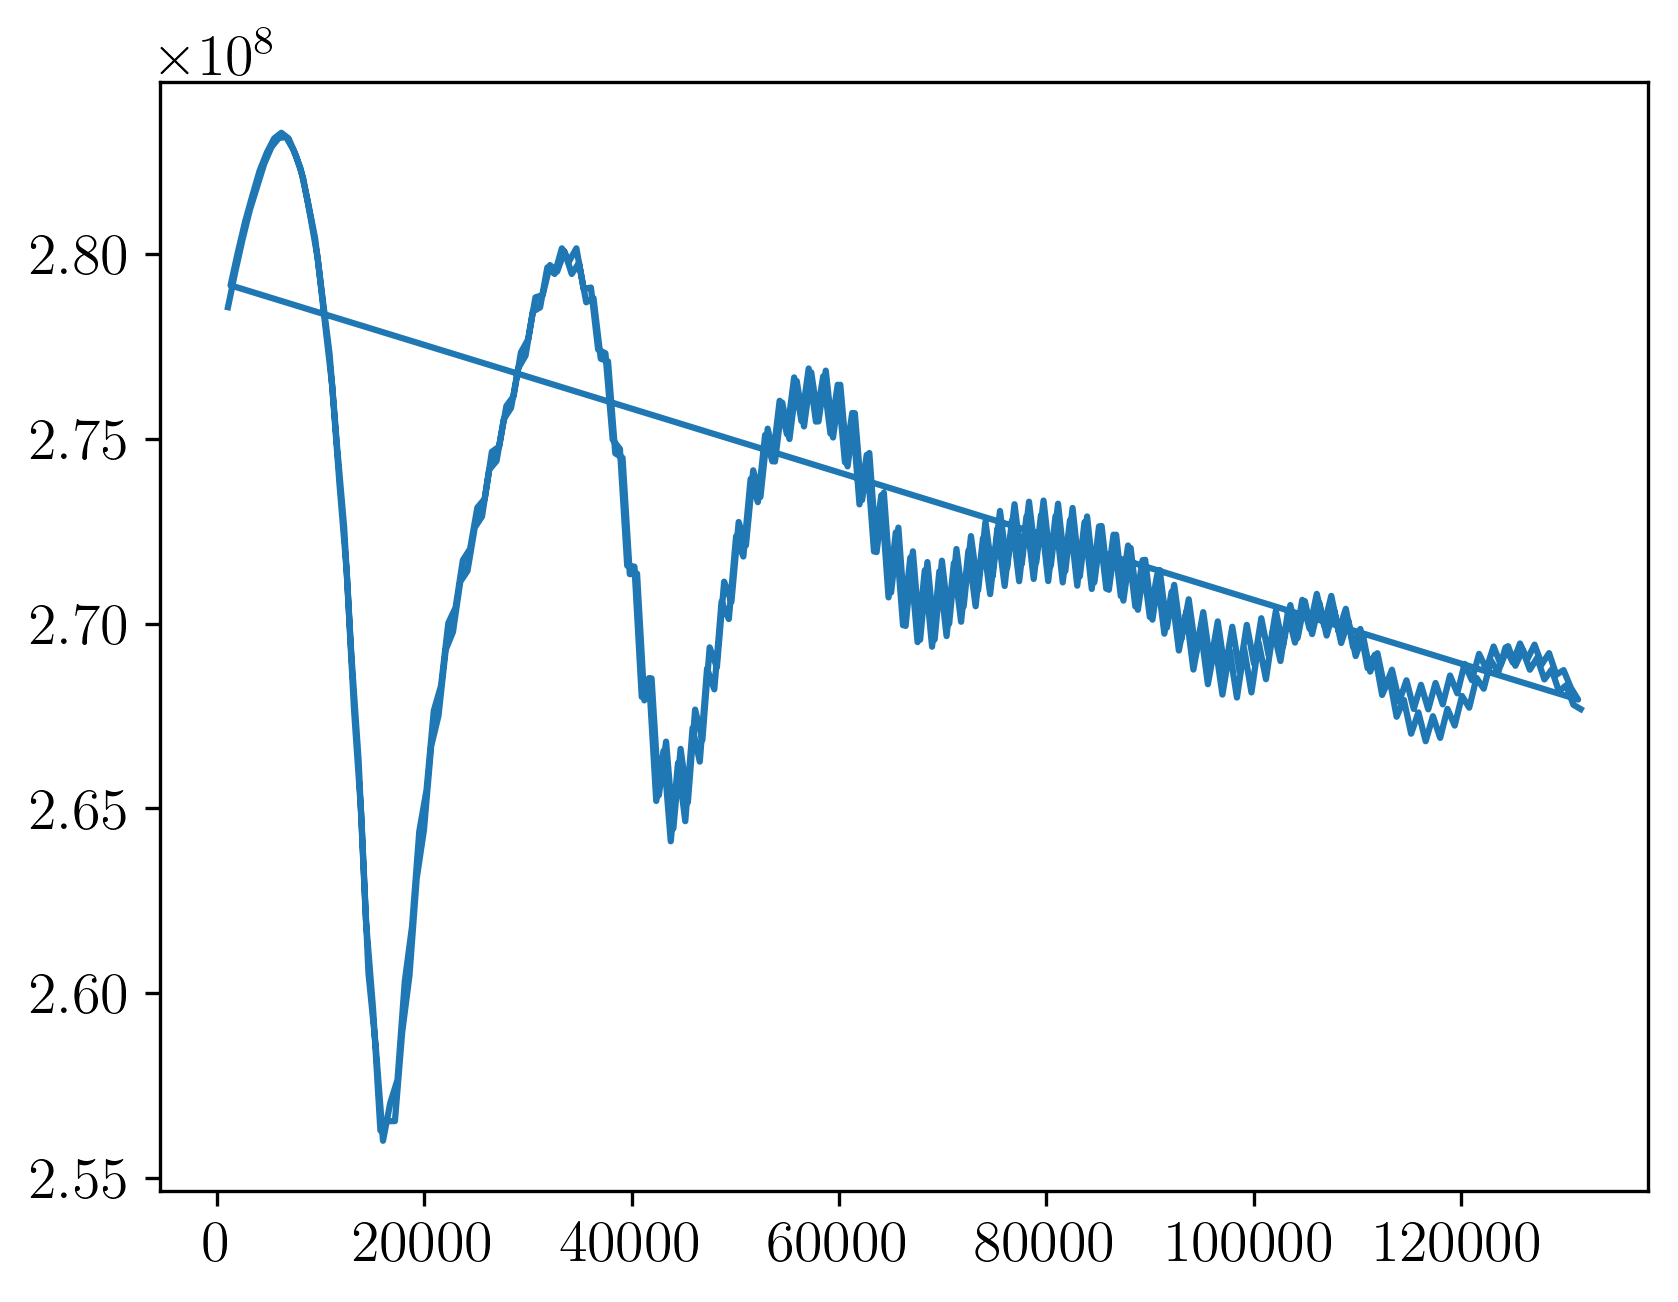

In [277]:
plt.plot(zvals,avgvvals)

In [278]:
uniqueIDs = data_middle['EventID'][data_middle['z']==np.min(data_middle['z'])].values
bool_list = np.isin(uniqueIDs,data_middle['EventID'][data_middle['z']==np.max(data_middle['z'])])
survIDs = []
for i in range(len(bool_list)):
    if bool_list[i] == True:
        survIDs.append(uniqueIDs[i])

In [279]:
data_middle_surv = data_middle[np.isin(data_middle['EventID'],survIDs)]
data_start_surv = data_start[np.isin(data_start['EventID'],survIDs)]

In [280]:
avgpvals = []
zvals = []
for z in unique_z_start:
    zvals.append(z)
    avgpvals.append(np.average(data_start_surv['pz'][data_start_surv['z']==z]))
for z in unique_z_middle:
    zvals.append(z)
    avgpvals.append(np.average(data_middle_surv['pz'][data_middle_surv['z']==z]))

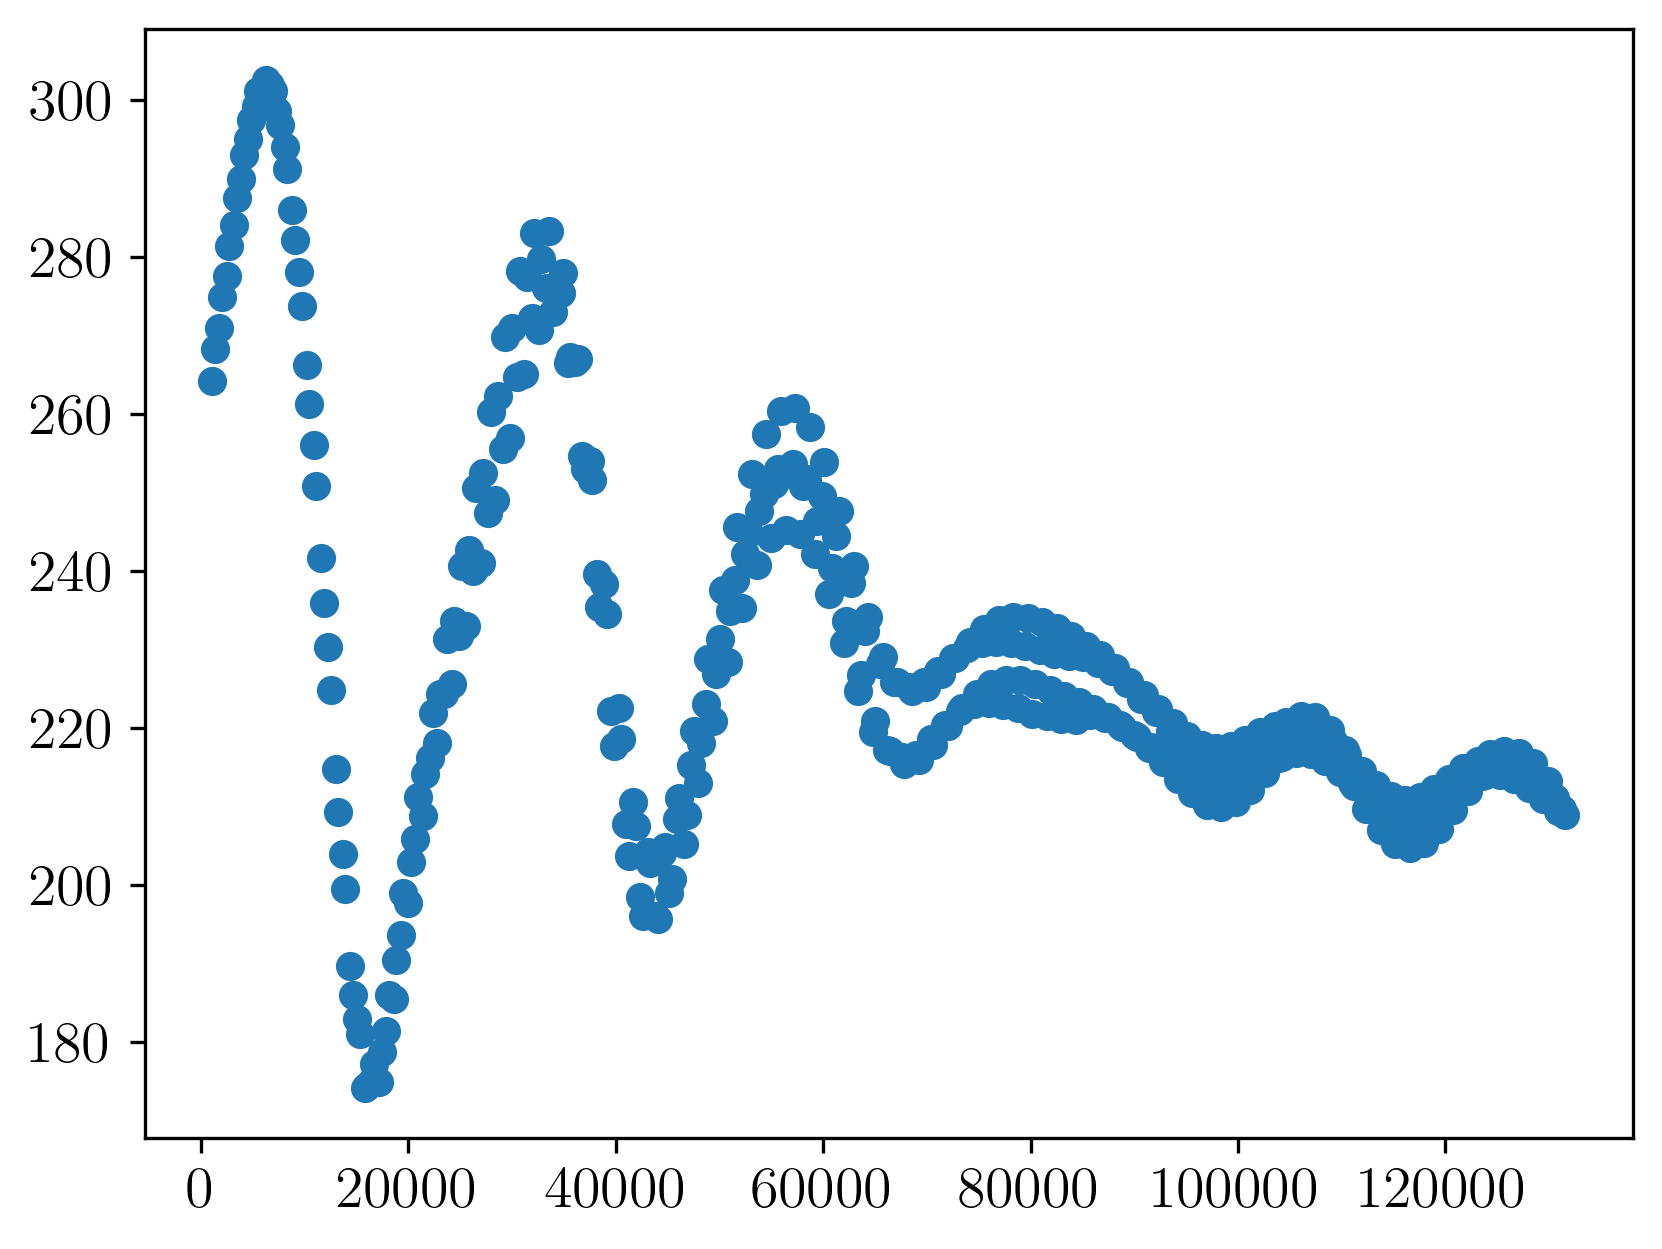

In [281]:
plt.scatter(zvals,avgpvals)

In [282]:
len(zvals)

374

In [283]:
len(np.unique(zvals))

374

In [284]:
avgvvals = []
for p in avgpvals:
    avgvvals.append(v(p))

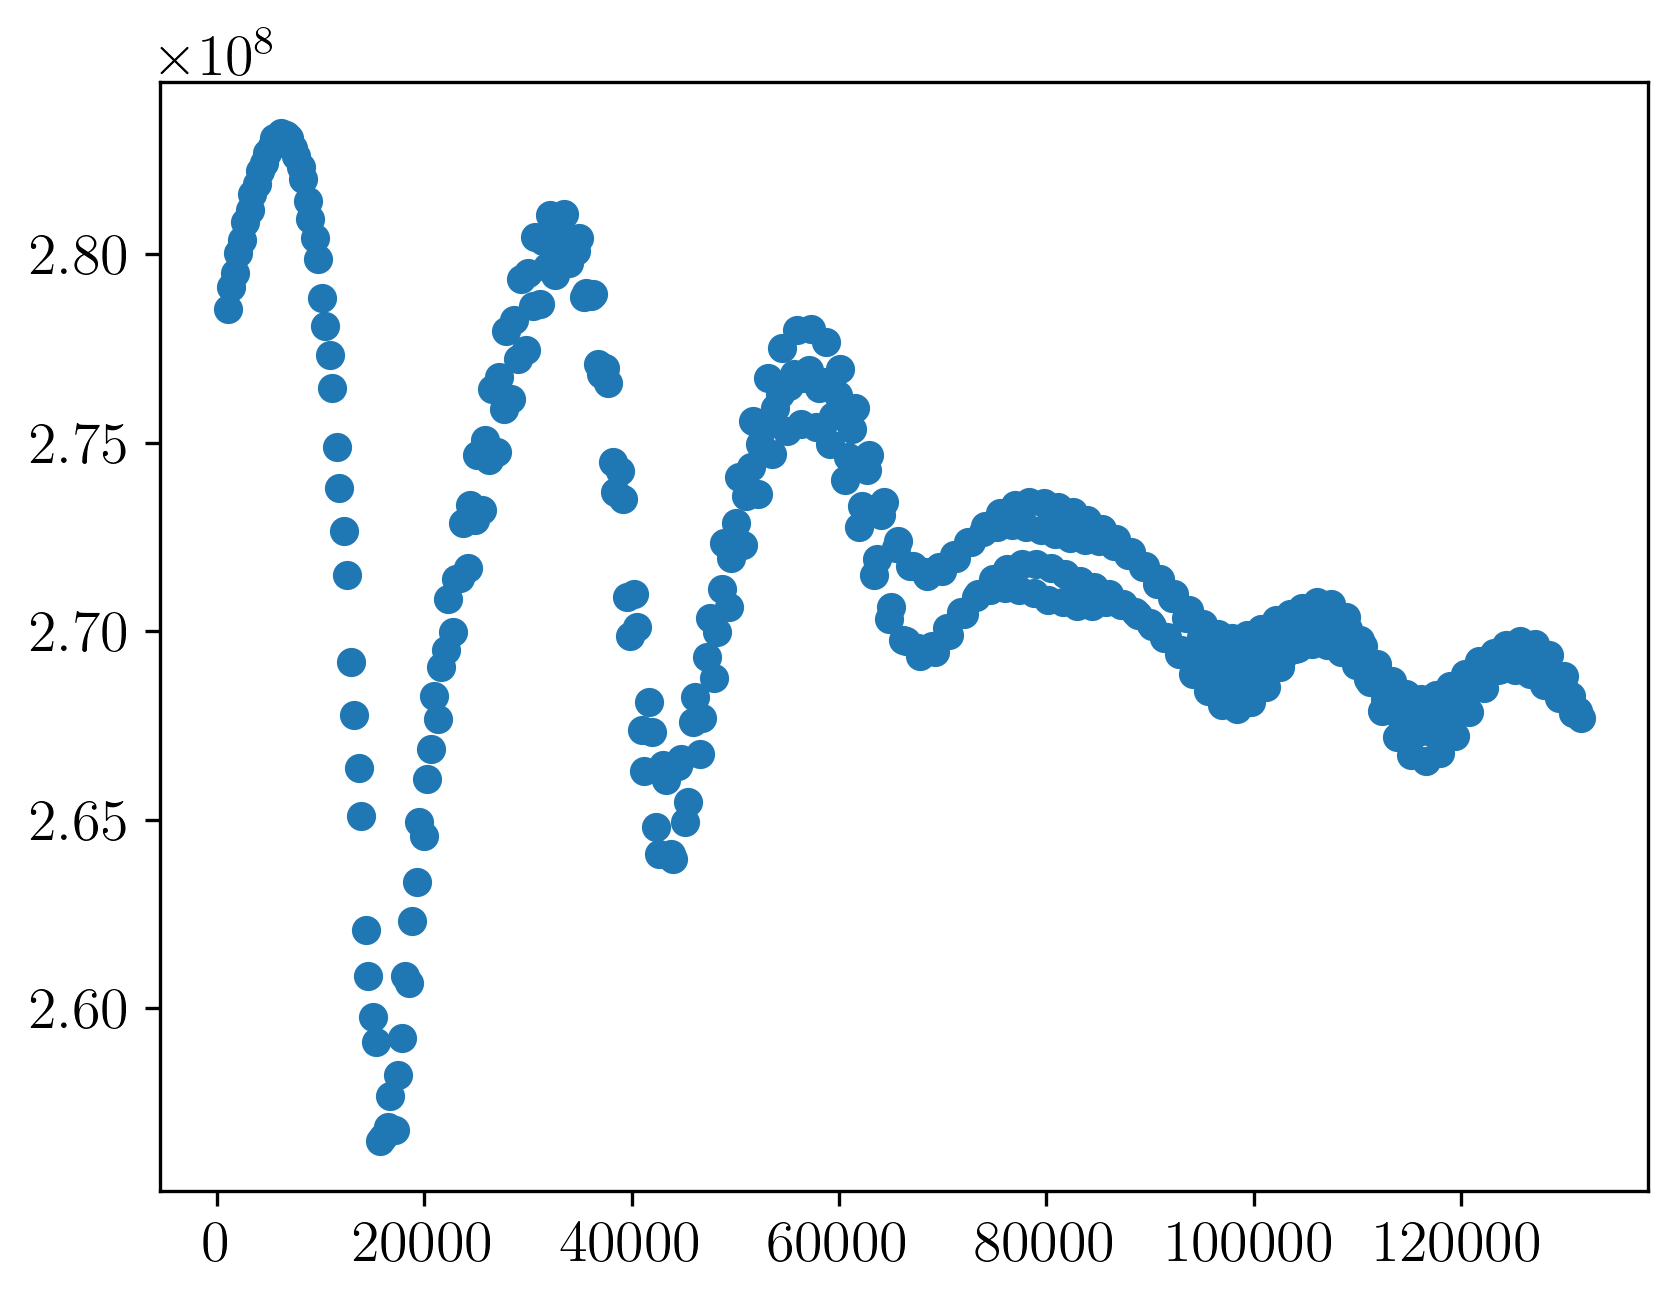

In [285]:
plt.scatter(zvals,avgvvals)

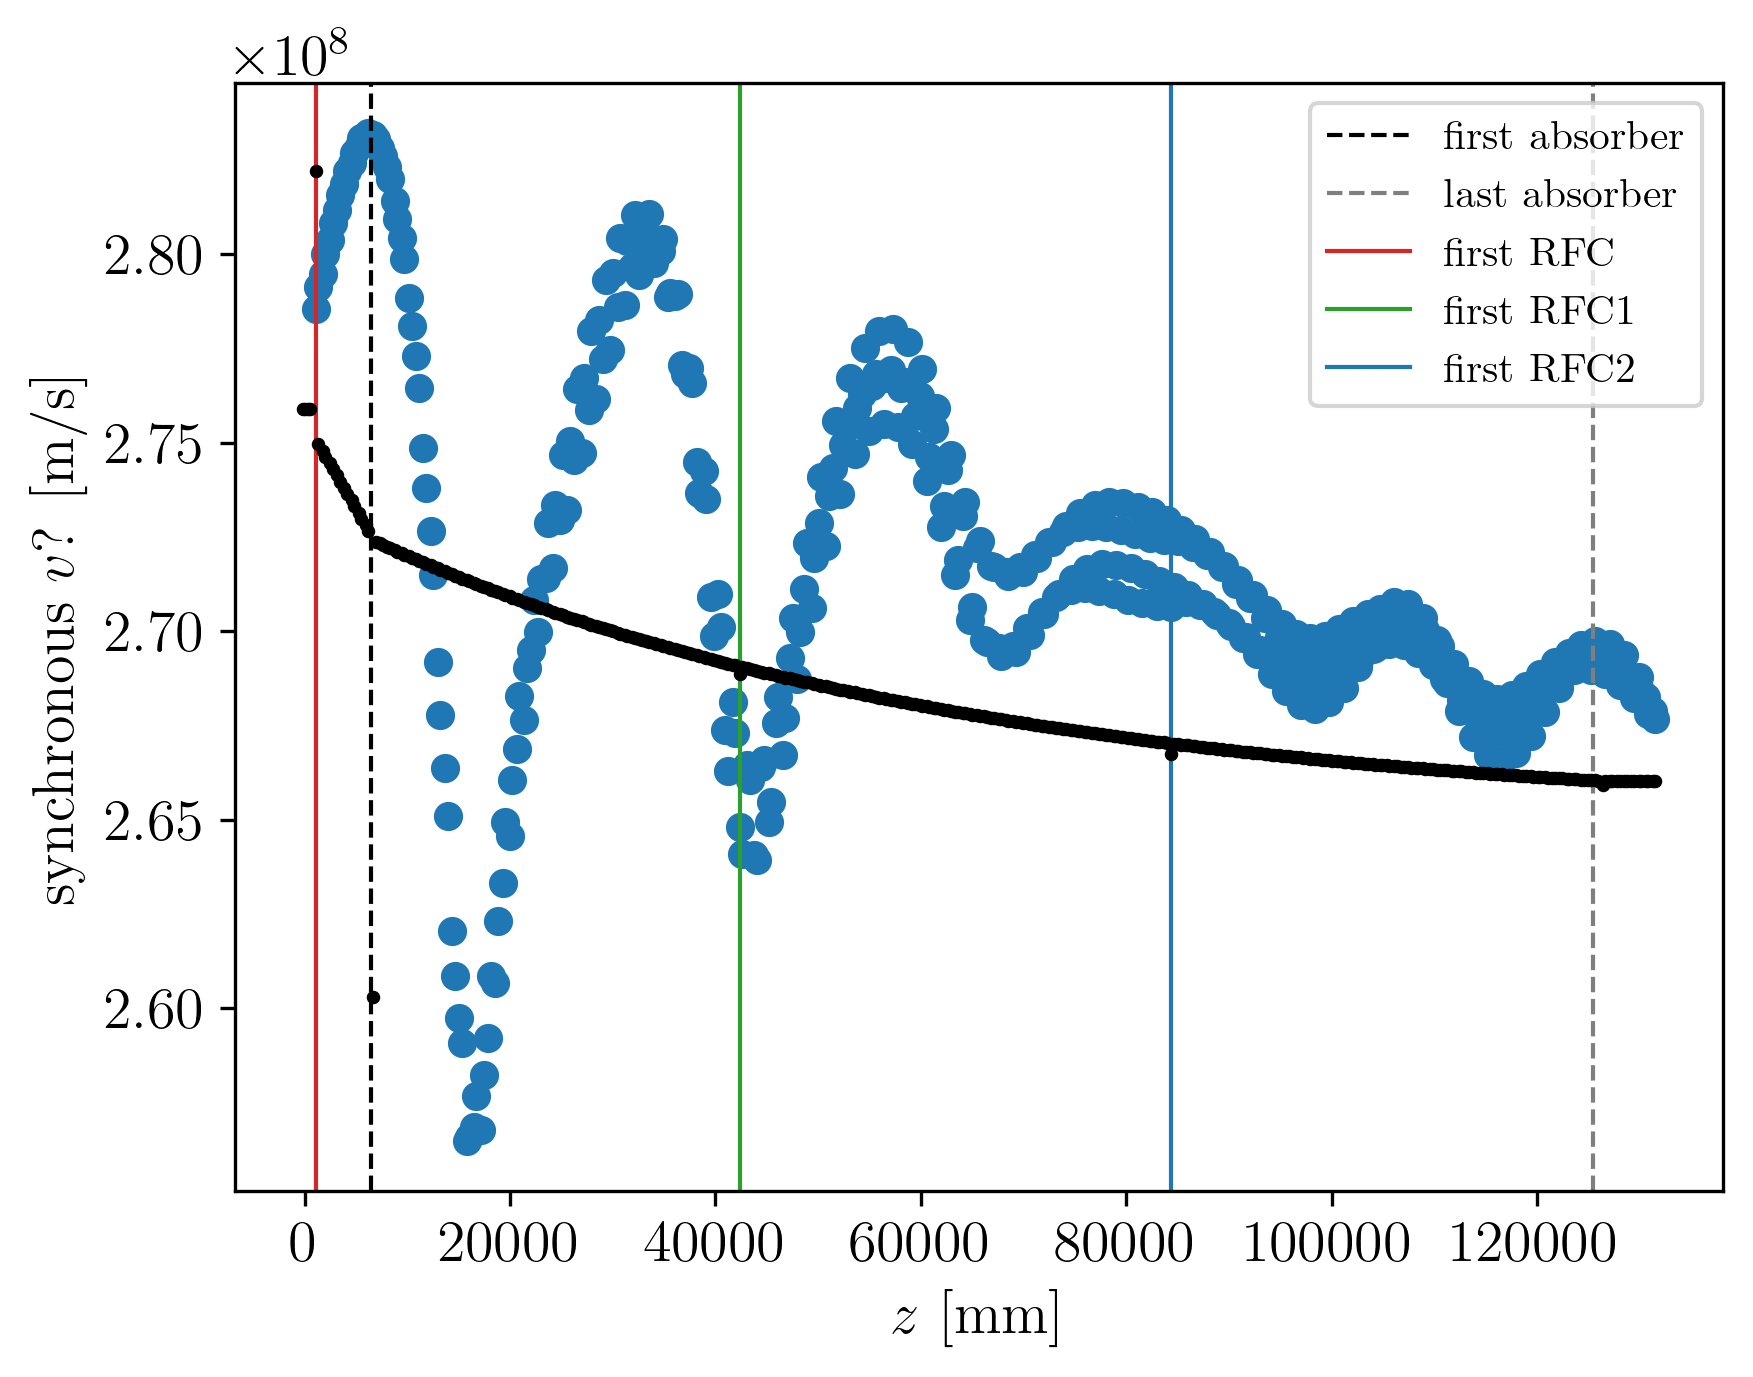

In [286]:
zvals2 = toffs['z'].values[1:]
plt.scatter(zvals2,vs,s=5,color='black',zorder=10)
plt.axvline(zabsi,label='first absorber',color='black',linestyle='--',linewidth=1)
plt.axvline(zabsf,label='last absorber',color='tab:gray',linestyle='--',linewidth=1)
plt.axvline(1075,label='first RFC',color='tab:red',linewidth=1)
plt.axvline(42375,label='first RFC1',color='tab:green',linewidth=1)
plt.axvline(84375,label='first RFC2',color='tab:blue',linewidth=1)
plt.scatter(zvals,avgvvals)
plt.xlabel('$z$ [mm]')
plt.ylabel('synchronous $v$? [m/s]')
plt.legend(loc='upper right',fontsize=10);